 # ------------------- Optimised Models  ------------------- 

# Imports

In [2]:
# Complete the library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
from scipy.stats import ttest_rel, wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Data Loading and Initial Exploration

In [3]:
print("=" * 45)
print("Objective: Load same data as final_baseline_models")
print("Focus: Understand data structure and target distribution")
print()

# Load the data from the same source as final_baseline_models
df = pd.read_excel('MS_Capstone_Final_Quality_Check_Summary.xlsx', sheet_name='clean_data')

print("Data loaded successfully")
print(f"Dataset shape: {df.shape}")
print(f"   - Rows (observations): {df.shape[0]}")
print(f"   - Columns (features): {df.shape[1]}")
print()

# Display basic information about the dataset
print("DATASET OVERVIEW:")
print("=" * 25)
print("Column names and types:")
print(df.dtypes)
print()

# Check the target variable (same as baseline models)
target_col = 'Movement Label (1,0)'
if target_col in df.columns:
    print(f"TARGET VARIABLE: {target_col}")
    print("Target distribution:")
    target_counts = df[target_col].value_counts()
    print(target_counts)
    print(f"   - Class balance: {target_counts[1]}/{target_counts[0]} (Up/Down)")
    print(f"   - Percentage Up: {target_counts[1]/len(df)*100:.1f}%")
    print(f"   - Percentage Down: {target_counts[0]/len(df)*100:.1f}%")
else:
    print("Target variable not found. Available columns:")
    print(df.columns.tolist())

print()


Objective: Load same data as final_baseline_models
Focus: Understand data structure and target distribution

Data loaded successfully
Dataset shape: (585, 32)
   - Rows (observations): 585
   - Columns (features): 32

DATASET OVERVIEW:
Column names and types:
Company                                object
Ticker                                 object
AV_Ticker.BSE                          object
Sector                                 object
Cap Category                           object
Period                                 object
Sales                                 float64
Expenses                              float64
Operating Profit                      float64
OPM %                                 float64
Other Income                          float64
Interest                              float64
Depreciation                          float64
Profit before tax                     float64
Tax %                                 float64
Net Profit                            float64
EPS 

# Feature Selection and Data Preprocessing

In [5]:
print("=" * 50)
print("Objective: Select same predictors as final_baseline_models")
print("Focus: Handle NaN values and categorical variables")
print()

# First, check for NaN values in target variable
print("TARGET VARIABLE ANALYSIS:")
print("=" * 30)
target_col = 'Movement Label (1,0)'
print(f"Target column: {target_col}")
print(f"Total NaN in target: {df[target_col].isnull().sum()}")
print(f"Target data type: {df[target_col].dtype}")

# Remove rows with NaN target values
initial_rows = len(df)
df_clean = df.dropna(subset=[target_col]).copy()
rows_removed = initial_rows - len(df_clean)

print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after removing NaN targets: {len(df_clean)}")
print(f"Rows removed: {rows_removed}")
print()

# Define feature columns (same as baseline models - financial indicators only)
print("FEATURE SELECTION:")
print("=" * 25)

# Exclude non-predictive columns (identifiers, dates, target)
exclude_cols = [
    'Company', 'Ticker', 'AV_Ticker.BSE', 'Period',  # Identifiers
    'Result Date', '_T_date', '_T1_date', '_T2_date', '_T3_date',  # Dates
    'Movement Label (1,0)', # Target variable
    # FUTURE INFORMATION FEATURES (DATA LEAKAGE)
    'Closing Price (T)',           # Price on result day
    'Closing Price (T+1)',         # Price 1 day after result
    'Closing Price (T+2)',         # Price 2 days after result  
    'Closing Price (T+3)',         # Price 3 days after result
    '3-Day Avg Price Post Result', # Average price AFTER result
    '3-Day Return (%)' 
]

# Identify numerical financial indicators
numerical_features = []
categorical_features = []

for col in df_clean.columns:
    if col not in exclude_cols:
        if df_clean[col].dtype in ['int64', 'float64']:
            numerical_features.append(col)
        elif df_clean[col].dtype == 'object':
            categorical_features.append(col)

print(f"Numerical features identified: {len(numerical_features)}")
print("Numerical features:", numerical_features[:10], "..." if len(numerical_features) > 10 else "")
print()
print(f"Categorical features identified: {len(categorical_features)}")
print("Categorical features:", categorical_features)
print()

# Check for missing values in features
print("MISSING VALUES ANALYSIS:")
print("=" * 30)
all_features = numerical_features + categorical_features
missing_summary = df_clean[all_features].isnull().sum()
features_with_missing = missing_summary[missing_summary > 0]

if len(features_with_missing) > 0:
    print("Features with missing values:")
    for feature, count in features_with_missing.items():
        percentage = (count / len(df_clean)) * 100
        print(f"   {feature}: {count} ({percentage:.1f}%)")
else:
    print("No missing values in feature columns")

print()


Objective: Select same predictors as final_baseline_models
Focus: Handle NaN values and categorical variables

TARGET VARIABLE ANALYSIS:
Target column: Movement Label (1,0)
Total NaN in target: 1
Target data type: float64
Rows before cleaning: 585
Rows after removing NaN targets: 584
Rows removed: 1

FEATURE SELECTION:
Numerical features identified: 14
Numerical features: ['Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income', 'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit'] ...

Categorical features identified: 2
Categorical features: ['Sector', 'Cap Category']

MISSING VALUES ANALYSIS:
Features with missing values:
   Sales: 117 (20.0%)
   Operating Profit: 117 (20.0%)
   OPM %: 117 (20.0%)
   Revenue: 467 (80.0%)
   Financing Profit: 467 (80.0%)
   Financing Margin %: 467 (80.0%)



# Data Preparation Pipeline 

In [6]:
print("=" * 50)
print("Objective: Create robust preprocessing pipeline")
print("Focus: Keep all features to preserve sector representation")
print()

# First, let's analyze the sector distribution and missing values by sector
print("SECTOR ANALYSIS WITH MISSING VALUES:")
print("=" * 40)

# Check sector distribution
sector_dist = df_clean['Sector'].value_counts()
print("Sector distribution:")
print(sector_dist)
print()

# Check which sectors have the missing financial data
missing_features = ['Revenue', 'Financing Profit', 'Financing Margin %']
print("Missing values analysis by sector:")
for feature in missing_features:
    print(f"\
{feature}:")
    missing_by_sector = df_clean.groupby('Sector')[feature].apply(lambda x: x.isnull().sum())
    total_by_sector = df_clean.groupby('Sector')[feature].apply(lambda x: len(x))
    missing_pct_by_sector = (missing_by_sector / total_by_sector * 100).round(1)
    
    for sector in sector_dist.index:
        missing_count = missing_by_sector.get(sector, 0)
        total_count = total_by_sector.get(sector, 0)
        missing_pct = missing_pct_by_sector.get(sector, 0)
        print(f"   {sector}: {missing_count}/{total_count} ({missing_pct}%) missing")

print()

# Keep all features but use sector-aware imputation
print("📊 REVISED FEATURE SELECTION STRATEGY:")
print("=" * 40)
print("Keeping ALL features to preserve sector representation")
print("Using sector-aware imputation for missing values")
print()

# Keep all features
all_features = numerical_features + categorical_features
final_numerical_features = numerical_features.copy()
final_categorical_features = categorical_features.copy()

print(f"Total numerical features: {len(final_numerical_features)}")
print(f"Total categorical features: {len(final_categorical_features)}")
print("Categorical features:", final_categorical_features)
print()

# Prepare the final dataset
print("PREPARING FINAL DATASET:")
print("=" * 30)

# Create feature matrix X and target vector y
X = df_clean[all_features].copy()
y = df_clean[target_col].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print()

# SECTOR-AWARE IMPUTATION STRATEGY
print("SECTOR-AWARE MISSING VALUE HANDLING:")
print("=" * 40)

# For numerical features: use sector-specific median, fallback to overall median
for feature in final_numerical_features:
    if X[feature].isnull().sum() > 0:
        print(f"Imputing {feature}:")
        
        # Calculate sector-specific medians
        sector_medians = df_clean.groupby('Sector')[feature].median()
        overall_median = df_clean[feature].median()
        
        # Apply sector-specific imputation
        for sector in df_clean['Sector'].unique():
            sector_mask = (X['Sector'] == sector) & X[feature].isnull()
            if sector_mask.sum() > 0:
                # Use sector median if available, otherwise overall median
                impute_value = sector_medians.get(sector, overall_median)
                if pd.isna(impute_value):
                    impute_value = overall_median
                
                X.loc[sector_mask, feature] = impute_value
                print(f"   {sector}: {sector_mask.sum()} values imputed with {impute_value:.2f}")

# For categorical features: use mode imputation
for feature in final_categorical_features:
    if X[feature].isnull().sum() > 0:
        mode_value = X[feature].mode()[0]
        X[feature] = X[feature].fillna(mode_value)
        print(f"   Imputed {feature} with mode: {mode_value}")

# Verify no missing values remain
remaining_missing = X.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

if remaining_missing == 0:
    print("All missing values handled successfully")
    print("All sectors preserved with complete feature representation")
else:
    print("Some missing values remain - need additional handling")

print()


Objective: Create robust preprocessing pipeline
Focus: Keep all features to preserve sector representation

SECTOR ANALYSIS WITH MISSING VALUES:
Sector distribution:
Sector
IT / Technology    117
BFSI               117
FMCG               117
Pharma             117
Auto               116
Name: count, dtype: int64

Missing values analysis by sector:
Revenue:
   IT / Technology: 117/117 (100.0%) missing
   BFSI: 0/117 (0.0%) missing
   FMCG: 117/117 (100.0%) missing
   Pharma: 117/117 (100.0%) missing
   Auto: 116/116 (100.0%) missing
Financing Profit:
   IT / Technology: 117/117 (100.0%) missing
   BFSI: 0/117 (0.0%) missing
   FMCG: 117/117 (100.0%) missing
   Pharma: 117/117 (100.0%) missing
   Auto: 116/116 (100.0%) missing
Financing Margin %:
   IT / Technology: 117/117 (100.0%) missing
   BFSI: 0/117 (0.0%) missing
   FMCG: 117/117 (100.0%) missing
   Pharma: 117/117 (100.0%) missing
   Auto: 116/116 (100.0%) missing

📊 REVISED FEATURE SELECTION STRATEGY:
Keeping ALL features to pre

# Pipeline Setup with Categorical Encoding
## --> Prevents data leakage (preprocessing only on training folds
## --> Ensures consistent preprocessing across CV folds
## --> Handles categorical variables properly
## --> Standardizes numerical features

In [8]:

print("=" * 55)
print("Objective: Create sklearn pipelines to prevent data leakage")
print("Focus: Proper preprocessing with categorical encoding")
print()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define preprocessing steps
print("PREPROCESSING PIPELINE SETUP:")
print("=" * 35)

# Separate numerical and categorical features for preprocessing
print(f"Numerical features ({len(final_numerical_features)}):")
print(final_numerical_features[:5], "..." if len(final_numerical_features) > 5 else "")
print()
print(f"Categorical features ({len(final_categorical_features)}):")
print(final_categorical_features)
print()

# Create preprocessing pipeline
# For numerical features: StandardScaler
numerical_transformer = StandardScaler()

# For categorical features: OneHotEncoder with drop='first' to avoid multicollinearity
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, final_numerical_features),
        ('cat', categorical_transformer, final_categorical_features)
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessing pipeline created:")
print("Numerical: StandardScaler (mean=0, std=1)")
print("Categorical: OneHotEncoder (drop='first', handle_unknown='ignore')")
print()

# Define the three models for comparison (RQ4)
print("MODEL DEFINITIONS (RQ4 - Model Comparison):")
print("=" * 50)

# Model 1: Logistic Regression
lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'  # Good for small datasets
)

# Model 2: Random Forest
rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all available cores
)

# Model 3: XGBoost
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0  # Suppress warnings
)

print("Models defined:")
print("Logistic Regression: Linear, interpretable baseline")
print("Random Forest: Bagging-based, handles non-linearity")
print("XGBoost: Gradient boosting, advanced ensemble method")
print()

# Create complete pipelines (preprocessing + model)
print("COMPLETE PIPELINES CREATION:")
print("=" * 35)

pipelines = {
    'Logistic_Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', lr_model)
    ]),
    'Random_Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ])
}

print("Complete pipelines created:")
for name, pipeline in pipelines.items():
    print(f"   🔗 {name}: Preprocessor → {pipeline.named_steps['classifier'].__class__.__name__}")

print()
print("🔧 Pipeline Benefits:")

print()


Objective: Create sklearn pipelines to prevent data leakage
Focus: Proper preprocessing with categorical encoding

PREPROCESSING PIPELINE SETUP:
Numerical features (14):
['Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income'] ...

Categorical features (2):
['Sector', 'Cap Category']

Preprocessing pipeline created:
Numerical: StandardScaler (mean=0, std=1)
Categorical: OneHotEncoder (drop='first', handle_unknown='ignore')

MODEL DEFINITIONS (RQ4 - Model Comparison):
Models defined:
Logistic Regression: Linear, interpretable baseline
Random Forest: Bagging-based, handles non-linearity
XGBoost: Gradient boosting, advanced ensemble method

COMPLETE PIPELINES CREATION:
Complete pipelines created:
   🔗 Logistic_Regression: Preprocessor → LogisticRegression
   🔗 Random_Forest: Preprocessor → RandomForestClassifier
   🔗 XGBoost: Preprocessor → XGBClassifier

🔧 Pipeline Benefits:



# Cross-Validation Setup and Baseline Performance

In [9]:

print("=" * 60)
print("Objective: Establish robust CV framework and baseline metrics")
print("Focus: 5-fold CV with comprehensive metrics")
print()

from tqdm import tqdm
import time

# Set up cross-validation
print("CROSS-VALIDATION SETUP:")
print("=" * 30)

# Use StratifiedKFold to maintain class balance across folds
from sklearn.model_selection import StratifiedKFold

cv_folds = 5
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

print(f"Cross-validation configured:")
print(f"Method: StratifiedKFold")
print(f"Folds: {cv_folds}")
print(f"Shuffle: True (random_state={RANDOM_STATE})")
print(f"Maintains class balance across folds")
print()

# Define comprehensive scoring metrics
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("EVALUATION METRICS:")
print("=" * 25)
for metric_name, metric_func in scoring_metrics.items():
    print(f"   ✅ {metric_name.upper()}: {metric_func}")
print()

# Perform cross-validation for all models
print("BASELINE MODEL EVALUATION:")
print("=" * 35)
print("Running 5-fold cross-validation for each model...")
print()

baseline_results = {}

for model_name, pipeline in tqdm(pipelines.items(), desc="Evaluating Models"):
    print(f"Evaluating {model_name}...")
    
    # Perform cross-validation
    start_time = time.time()
    cv_results = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1  # Use all available cores
    )
    end_time = time.time()
    
    # Store results
    baseline_results[model_name] = cv_results
    
    # Display results
    print(f"Training time: {end_time - start_time:.2f} seconds")
    print(f"Results (mean ± std):")
    
    for metric in scoring_metrics.keys():
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']
        
        test_mean = test_scores.mean()
        test_std = test_scores.std()
        train_mean = train_scores.mean()
        train_std = train_scores.std()
        
        # Calculate overfitting indicator (train - test)
        overfitting = train_mean - test_mean
        
        print(f"      {metric.upper():>8}: Test={test_mean:.3f}±{test_std:.3f} | Train={train_mean:.3f}±{train_std:.3f} | Gap={overfitting:.3f}")
    
    print()

print("Baseline evaluation complete!")
print()

# Summary comparison
print("📋 BASELINE PERFORMANCE SUMMARY:")
print("=" * 40)
print(f"{'Model':<20} {'Accuracy':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Overfitting':<12}")
print("-" * 68)

for model_name in baseline_results.keys():
    results = baseline_results[model_name]
    
    accuracy = results['test_accuracy'].mean()
    f1 = results['test_f1'].mean()
    roc_auc = results['test_roc_auc'].mean()
    
    # Calculate overfitting as difference between train and test accuracy
    overfitting = results['train_accuracy'].mean() - results['test_accuracy'].mean()
    
    print(f"{model_name:<20} {accuracy:<12.3f} {f1:<12.3f} {roc_auc:<12.3f} {overfitting:<12.3f}")

print()


Objective: Establish robust CV framework and baseline metrics
Focus: 5-fold CV with comprehensive metrics

CROSS-VALIDATION SETUP:
Cross-validation configured:
Method: StratifiedKFold
Folds: 5
Shuffle: True (random_state=42)
Maintains class balance across folds

EVALUATION METRICS:
   ✅ ACCURACY: accuracy
   ✅ PRECISION: precision
   ✅ RECALL: recall
   ✅ F1: f1
   ✅ ROC_AUC: roc_auc

BASELINE MODEL EVALUATION:
Running 5-fold cross-validation for each model...



Evaluating Models:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Logistic_Regression...


Evaluating Models:  33%|███▎      | 1/3 [00:05<00:11,  5.76s/it]

Training time: 5.76 seconds
Results (mean ± std):
      ACCURACY: Test=0.572±0.038 | Train=0.607±0.012 | Gap=0.035
      PRECISION: Test=0.469±0.126 | Train=0.556±0.033 | Gap=0.088
        RECALL: Test=0.183±0.042 | Train=0.222±0.044 | Gap=0.039
            F1: Test=0.259±0.053 | Train=0.314±0.049 | Gap=0.055
       ROC_AUC: Test=0.552±0.046 | Train=0.621±0.011 | Gap=0.069

Evaluating Random_Forest...


Evaluating Models:  67%|██████▋   | 2/3 [00:11<00:05,  5.58s/it]

Training time: 5.45 seconds
Results (mean ± std):
      ACCURACY: Test=0.495±0.029 | Train=1.000±0.000 | Gap=0.505
      PRECISION: Test=0.365±0.034 | Train=1.000±0.000 | Gap=0.635
        RECALL: Test=0.308±0.031 | Train=1.000±0.000 | Gap=0.692
            F1: Test=0.334±0.030 | Train=1.000±0.000 | Gap=0.666
       ROC_AUC: Test=0.484±0.030 | Train=1.000±0.000 | Gap=0.516

Evaluating XGBoost...


Evaluating Models: 100%|██████████| 3/3 [00:22<00:00,  7.47s/it]

Training time: 11.21 seconds
Results (mean ± std):
      ACCURACY: Test=0.508±0.048 | Train=1.000±0.000 | Gap=0.492
      PRECISION: Test=0.396±0.051 | Train=1.000±0.000 | Gap=0.604
        RECALL: Test=0.354±0.026 | Train=1.000±0.000 | Gap=0.646
            F1: Test=0.373±0.033 | Train=1.000±0.000 | Gap=0.627
       ROC_AUC: Test=0.486±0.050 | Train=1.000±0.000 | Gap=0.514

Baseline evaluation complete!

📋 BASELINE PERFORMANCE SUMMARY:
Model                Accuracy     F1-Score     ROC-AUC      Overfitting 
--------------------------------------------------------------------
Logistic_Regression  0.572        0.259        0.552        0.035       
Random_Forest        0.495        0.334        0.484        0.505       
XGBoost              0.508        0.373        0.486        0.492       



# Hyperparameter Tuning with Clean Features

In [10]:

print("=" * 55)
print("Objective: Optimize models to reduce overfitting and improve generalization")
print("Focus: Grid search with regularization parameters")
print()

# Define hyperparameter grids focused on reducing overfitting
print("📋 HYPERPARAMETER GRIDS:")
print("=" * 30)

# Logistic Regression - regularization focused
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],  # Regularization strength
    'classifier__penalty': ['l1', 'l2'],  # Regularization type
    'classifier__solver': ['liblinear']  # Compatible with both l1 and l2
}

# Random Forest - overfitting reduction focused
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],  # Number of trees
    'classifier__max_depth': [3, 5, 10, None],  # Tree depth (key for overfitting)
    'classifier__min_samples_split': [5, 10, 20],  # Min samples to split
    'classifier__min_samples_leaf': [2, 5, 10],  # Min samples in leaf
    'classifier__max_features': ['sqrt', 'log2', 0.5]  # Feature sampling
}

# XGBoost - regularization and overfitting reduction
xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 200],  # Number of boosting rounds
    'classifier__max_depth': [3, 4, 6],  # Tree depth
    'classifier__learning_rate': [0.01, 0.1, 0.2],  # Learning rate
    'classifier__subsample': [0.8, 0.9, 1.0],  # Row sampling
    'classifier__colsample_bytree': [0.8, 0.9, 1.0],  # Column sampling
    'classifier__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'classifier__reg_lambda': [1, 1.5, 2]  # L2 regularization
}

print("Logistic Regression parameters:")
print(f"   C (regularization): {lr_param_grid['classifier__C']}")
print(f"   Penalty: {lr_param_grid['classifier__penalty']}")
print()

print("Random Forest parameters (overfitting reduction):")
print(f"   n_estimators: {rf_param_grid['classifier__n_estimators']}")
print(f"   max_depth: {rf_param_grid['classifier__max_depth']}")
print(f"   min_samples_split: {rf_param_grid['classifier__min_samples_split']}")
print(f"   min_samples_leaf: {rf_param_grid['classifier__min_samples_leaf']}")
print()

print("XGBoost parameters (regularization focused):")
print(f"   n_estimators: {xgb_param_grid['classifier__n_estimators']}")
print(f"   max_depth: {xgb_param_grid['classifier__max_depth']}")
print(f"   learning_rate: {xgb_param_grid['classifier__learning_rate']}")
print(f"   regularization: alpha={xgb_param_grid['classifier__reg_alpha']}, lambda={xgb_param_grid['classifier__reg_lambda']}")
print()

# Set up grid search parameters
print("GRID SEARCH CONFIGURATION:")
print("=" * 35)

# Use a smaller CV for grid search to speed up computation
grid_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring_metric = 'roc_auc'  # Primary metric for optimization
n_jobs = -1  # Use all available cores

print(f"Cross-validation: 3-fold StratifiedKFold")
print(f"Scoring metric: {scoring_metric}")
print(f"Parallel jobs: {n_jobs}")
print()

# Perform hyperparameter tuning
print("HYPERPARAMETER TUNING:")
print("=" * 30)

tuned_models = {}
tuning_results = {}

# 1. Logistic Regression Tuning
print("1. TUNING LOGISTIC REGRESSION:")
print("   Searching for optimal regularization...")

lr_grid_search = GridSearchCV(
    pipelines['Logistic_Regression'],
    lr_param_grid,
    cv=grid_cv,
    scoring=scoring_metric,
    n_jobs=n_jobs,
    verbose=1
)

start_time = time.time()
lr_grid_search.fit(X, y)
lr_time = time.time() - start_time

tuned_models['Logistic_Regression'] = lr_grid_search.best_estimator_
tuning_results['Logistic_Regression'] = {
    'best_params': lr_grid_search.best_params_,
    'best_score': lr_grid_search.best_score_,
    'tuning_time': lr_time
}

print(f"Best parameters: {lr_grid_search.best_params_}")
print(f"Best CV score: {lr_grid_search.best_score_:.3f}")
print(f"Tuning time: {lr_time:.1f} seconds")
print()

# 2. Random Forest Tuning (reduced grid for speed)
print("2. TUNING RANDOM FOREST:")
print("Searching for optimal complexity reduction...")

# Use a smaller grid for Random Forest due to computational cost
rf_small_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 10],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf': [5, 10],
    'classifier__max_features': ['sqrt', 0.5]
}

rf_grid_search = GridSearchCV(
    pipelines['Random_Forest'],
    rf_small_grid,
    cv=grid_cv,
    scoring=scoring_metric,
    n_jobs=n_jobs,
    verbose=1
)

start_time = time.time()
rf_grid_search.fit(X, y)
rf_time = time.time() - start_time

tuned_models['Random_Forest'] = rf_grid_search.best_estimator_
tuning_results['Random_Forest'] = {
    'best_params': rf_grid_search.best_params_,
    'best_score': rf_grid_search.best_score_,
    'tuning_time': rf_time
}

print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best CV score: {rf_grid_search.best_score_:.3f}")
print(f"Tuning time: {rf_time:.1f} seconds")
print()

# 3. XGBoost Tuning (reduced grid for speed)
print("3. TUNING XGBOOST:")
print("Searching for optimal regularization and complexity...")

# Use a smaller grid for XGBoost
xgb_small_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 4],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1],
    'classifier__reg_lambda': [1, 2]
}

xgb_grid_search = GridSearchCV(
    pipelines['XGBoost'],
    xgb_small_grid,
    cv=grid_cv,
    scoring=scoring_metric,
    n_jobs=n_jobs,
    verbose=1
)

start_time = time.time()
xgb_grid_search.fit(X, y)
xgb_time = time.time() - start_time

tuned_models['XGBoost'] = xgb_grid_search.best_estimator_
tuning_results['XGBoost'] = {
    'best_params': xgb_grid_search.best_params_,
    'best_score': xgb_grid_search.best_score_,
    'tuning_time': xgb_time
}

print(f"Best parameters: {xgb_grid_search.best_params_}")
print(f"Best CV score: {xgb_grid_search.best_score_:.3f}")
print(f"Tuning time: {xgb_time:.1f} seconds")
print()

print("Hyperparameter tuning complete!")
print()

# Display tuning summary
print("HYPERPARAMETER TUNING SUMMARY:")
print("=" * 40)
print(f"{'Model':<20} {'Best CV Score':<15} {'Tuning Time':<15}")
print("-" * 50)

for model_name, results in tuning_results.items():
    print(f"{model_name:<20} {results['best_score']:<15.3f} {results['tuning_time']:<15.1f}s")

print()


Objective: Optimize models to reduce overfitting and improve generalization
Focus: Grid search with regularization parameters

📋 HYPERPARAMETER GRIDS:
Logistic Regression parameters:
   C (regularization): [0.001, 0.01, 0.1, 1.0, 10.0]
   Penalty: ['l1', 'l2']

Random Forest parameters (overfitting reduction):
   n_estimators: [50, 100, 200]
   max_depth: [3, 5, 10, None]
   min_samples_split: [5, 10, 20]
   min_samples_leaf: [2, 5, 10]

XGBoost parameters (regularization focused):
   n_estimators: [50, 100, 200]
   max_depth: [3, 4, 6]
   learning_rate: [0.01, 0.1, 0.2]
   regularization: alpha=[0, 0.1, 1], lambda=[1, 1.5, 2]

GRID SEARCH CONFIGURATION:
Cross-validation: 3-fold StratifiedKFold
Scoring metric: roc_auc
Parallel jobs: -1

HYPERPARAMETER TUNING:
1. TUNING LOGISTIC REGRESSION:
   Searching for optimal regularization...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'lib

# Tuned Model Evaluation and Comparison

In [11]:
print("=" * 50)
print("Objective: Evaluate tuned models and compare with baseline performance")
print("Focus: Cross-validation evaluation and overfitting analysis")
print()

# Evaluate tuned models with 5-fold CV to compare with baseline
print("EVALUATING TUNED MODELS:")
print("=" * 35)

tuned_cv_results = {}

for model_name, tuned_model in tqdm(tuned_models.items(), desc="Evaluating Tuned Models"):
    print(f"Evaluating tuned {model_name}...")
    
    # Perform cross-validation
    start_time = time.time()
    cv_results = cross_validate(
        tuned_model, X, y,
        cv=cv,  # Use same 5-fold CV as baseline
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1
    )
    end_time = time.time()
    
    # Store results
    tuned_cv_results[model_name] = cv_results
    
    # Display results
    print(f"Evaluation time: {end_time - start_time:.2f} seconds")
    print(f"Results (mean ± std):")
    
    for metric in scoring_metrics.keys():
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']
        
        test_mean = test_scores.mean()
        test_std = test_scores.std()
        train_mean = train_scores.mean()
        train_std = train_scores.std()
        
        # Calculate overfitting indicator (train - test)
        overfitting = train_mean - test_mean
        
        print(f"      {metric.upper():>8}: Test={test_mean:.3f}±{test_std:.3f} | Train={train_mean:.3f}±{train_std:.3f} | Gap={overfitting:.3f}")
    
    print()


Objective: Evaluate tuned models and compare with baseline performance
Focus: Cross-validation evaluation and overfitting analysis

EVALUATING TUNED MODELS:


Evaluating Tuned Models:  33%|███▎      | 1/3 [00:00<00:00,  6.53it/s]

Evaluating tuned Logistic_Regression...
Evaluation time: 0.15 seconds
Results (mean ± std):
      ACCURACY: Test=0.586±0.007 | Train=0.592±0.002 | Gap=0.007
      PRECISION: Test=0.100±0.200 | Train=0.661±0.365 | Gap=0.561
        RECALL: Test=0.004±0.008 | Train=0.014±0.012 | Gap=0.009
            F1: Test=0.008±0.016 | Train=0.026±0.023 | Gap=0.018
       ROC_AUC: Test=0.547±0.027 | Train=0.564±0.008 | Gap=0.017

Evaluating tuned Random_Forest...


Evaluating Tuned Models: 100%|██████████| 3/3 [00:00<00:00,  3.32it/s]

Evaluation time: 0.54 seconds
Results (mean ± std):
      ACCURACY: Test=0.581±0.021 | Train=0.642±0.016 | Gap=0.062
      PRECISION: Test=0.418±0.169 | Train=0.823±0.020 | Gap=0.405
        RECALL: Test=0.079±0.044 | Train=0.164±0.048 | Gap=0.084
            F1: Test=0.132±0.070 | Train=0.270±0.070 | Gap=0.138
       ROC_AUC: Test=0.527±0.033 | Train=0.751±0.010 | Gap=0.223

Evaluating tuned XGBoost...
Evaluation time: 0.21 seconds
Results (mean ± std):
      ACCURACY: Test=0.570±0.019 | Train=0.652±0.013 | Gap=0.082
      PRECISION: Test=0.402±0.129 | Train=0.883±0.039 | Gap=0.481
        RECALL: Test=0.079±0.046 | Train=0.179±0.044 | Gap=0.100
            F1: Test=0.127±0.063 | Train=0.295±0.060 | Gap=0.167
       ROC_AUC: Test=0.527±0.039 | Train=0.791±0.006 | Gap=0.263



Evaluating Tuned Models: 100%|██████████| 3/3 [00:00<00:00,  3.33it/s]


In [12]:
# Compare baseline vs tuned performance
print("BASELINE vs TUNED COMPARISON:")
print("=" * 40)
print("Key Metrics: Accuracy, F1-Score, ROC-AUC, Overfitting Gap")
print()

comparison_data = []
clean_baseline_results = baseline_results

for model_name in clean_baseline_results.keys():
    # Baseline results
    baseline_results = clean_baseline_results[model_name]
    baseline_accuracy = baseline_results['test_accuracy'].mean()
    baseline_f1 = baseline_results['test_f1'].mean()
    baseline_roc = baseline_results['test_roc_auc'].mean()
    baseline_gap = baseline_results['train_accuracy'].mean() - baseline_results['test_accuracy'].mean()
    
    # Tuned results
    tuned_results = tuned_cv_results[model_name]
    tuned_accuracy = tuned_results['test_accuracy'].mean()
    tuned_f1 = tuned_results['test_f1'].mean()
    tuned_roc = tuned_results['test_roc_auc'].mean()
    tuned_gap = tuned_results['train_accuracy'].mean() - tuned_results['test_accuracy'].mean()
    
    # Calculate improvements
    acc_improvement = tuned_accuracy - baseline_accuracy
    f1_improvement = tuned_f1 - baseline_f1
    roc_improvement = tuned_roc - baseline_roc
    gap_reduction = baseline_gap - tuned_gap  # Positive means overfitting reduced
    
    comparison_data.append({
        'Model': model_name,
        'Baseline_Acc': baseline_accuracy,
        'Tuned_Acc': tuned_accuracy,
        'Acc_Change': acc_improvement,
        'Baseline_F1': baseline_f1,
        'Tuned_F1': tuned_f1,
        'F1_Change': f1_improvement,
        'Baseline_ROC': baseline_roc,
        'Tuned_ROC': tuned_roc,
        'ROC_Change': roc_improvement,
        'Baseline_Gap': baseline_gap,
        'Tuned_Gap': tuned_gap,
        'Gap_Reduction': gap_reduction
    })

# Display comparison table
print(f"{'Model':<20} {'Metric':<12} {'Baseline':<10} {'Tuned':<10} {'Change':<10} {'Status':<15}")
print("-" * 85)

for data in comparison_data:
    model = data['Model']
    
    # Accuracy row
    acc_status = " Improved" if data['Acc_Change'] > 0 else " Declined" if data['Acc_Change'] < 0 else "➖ Same"
    print(f"{model:<20} {'Accuracy':<12} {data['Baseline_Acc']:<10.3f} {data['Tuned_Acc']:<10.3f} {data['Acc_Change']:<+10.3f} {acc_status:<15}")
    
    # F1 row
    f1_status = " Improved" if data['F1_Change'] > 0 else " Declined" if data['F1_Change'] < 0 else "➖ Same"
    print(f"{'':<20} {'F1-Score':<12} {data['Baseline_F1']:<10.3f} {data['Tuned_F1']:<10.3f} {data['F1_Change']:<+10.3f} {f1_status:<15}")
    
    # ROC-AUC row
    roc_status = " Improved" if data['ROC_Change'] > 0 else " Declined" if data['ROC_Change'] < 0 else "➖ Same"
    print(f"{'':<20} {'ROC-AUC':<12} {data['Baseline_ROC']:<10.3f} {data['Tuned_ROC']:<10.3f} {data['ROC_Change']:<+10.3f} {roc_status:<15}")
    
    # Overfitting gap row
    gap_status = " Reduced" if data['Gap_Reduction'] > 0 else " Increased" if data['Gap_Reduction'] < 0 else "➖ Same"
    print(f"{'':<20} {'Overfitting':<12} {data['Baseline_Gap']:<10.3f} {data['Tuned_Gap']:<10.3f} {data['Gap_Reduction']:<+10.3f} {gap_status:<15}")
    
    print("-" * 85)

print()

# Summary insights
print(" TUNING IMPACT SUMMARY:")
print("=" * 30)

best_model = max(comparison_data, key=lambda x: x['Tuned_ROC'])
most_improved = max(comparison_data, key=lambda x: x['ROC_Change'])
best_overfitting_reduction = max(comparison_data, key=lambda x: x['Gap_Reduction'])

print(f"Best Overall Model: {best_model['Model']}")
print(f"ROC-AUC: {best_model['Tuned_ROC']:.3f}")
print(f"Accuracy: {best_model['Tuned_Acc']:.3f}")
print(f"Overfitting Gap: {best_model['Tuned_Gap']:.3f}")
print()

print(f"Most Improved Model: {most_improved['Model']}")
print(f"ROC-AUC improvement: {most_improved['ROC_Change']:+.3f}")
print()

print(f"Best Overfitting Reduction: {best_overfitting_reduction['Model']}")
print(f"Gap reduction: {best_overfitting_reduction['Gap_Reduction']:+.3f}")
print(f"From {best_overfitting_reduction['Baseline_Gap']:.3f} to {best_overfitting_reduction['Tuned_Gap']:.3f}")
print()


BASELINE vs TUNED COMPARISON:
Key Metrics: Accuracy, F1-Score, ROC-AUC, Overfitting Gap

Model                Metric       Baseline   Tuned      Change     Status         
-------------------------------------------------------------------------------------
Logistic_Regression  Accuracy     0.572      0.586      +0.014      Improved      
                     F1-Score     0.259      0.008      -0.251      Declined      
                     ROC-AUC      0.552      0.547      -0.005      Declined      
                     Overfitting  0.035      0.007      +0.028      Reduced       
-------------------------------------------------------------------------------------
Random_Forest        Accuracy     0.495      0.581      +0.086      Improved      
                     F1-Score     0.334      0.132      -0.202      Declined      
                     ROC-AUC      0.484      0.527      +0.044      Improved      
                     Overfitting  0.505      0.062      +0.444      Reduced

# Few more Imports required for Feature Analysis

In [13]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

print("=" * 25)
print("SHAP for model interpretation")
print("Permutation importance for feature ranking")
print("Visualization libraries")
print()

# Set up plotting parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 35)
print("Figure size: 12x8 inches")
print("Color palette: Husl")
print("Font size: 10pt")
print()

SHAP for model interpretation
Permutation importance for feature ranking
Visualization libraries

Figure size: 12x8 inches
Color palette: Husl
Font size: 10pt



# Feature Importance Analysis for All Models

In [14]:
print("=" * 55)
print("Objective: Extract and analyze feature importance from all tuned models")
print("Methods: Built-in feature importance for each model type")
print()

# 1. EXTRACT FEATURE IMPORTANCE FROM TUNED MODELS
print("STEP 1: EXTRACTING FEATURE IMPORTANCE")
print("=" * 40)

feature_importance_results = {}

# Get feature names from the pipeline
try:
    # Try to get feature names from the pipeline
    if hasattr(tuned_models['Logistic_Regression'], 'named_steps'):
        preprocessor = tuned_models['Logistic_Regression'].named_steps['preprocessor']
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            # Fallback: use the original feature names from X_clean
            feature_names = X_clean.columns.tolist()
    else:
        feature_names = X_clean.columns.tolist()

    print("Feature names extracted: " + str(len(feature_names)) + " features")
    print("Sample features: " + str(feature_names[:5]))

except Exception as e:
    print("Using fallback feature names: " + str(e))
    feature_names = X_clean.columns.tolist()

print()

# Extract feature importance for each model
for model_name, model in tuned_models.items():
    print("Extracting importance from " + model_name + "...")

    try:
        if model_name == 'Logistic_Regression':
            # For logistic regression, use coefficients
            if hasattr(model, 'named_steps'):
                classifier = model.named_steps['classifier']
            else:
                classifier = model

            if hasattr(classifier, 'coef_'):
                importances = np.abs(classifier.coef_[0])
            else:
                print("   No coefficients found for " + model_name)
                continue

        elif model_name in ['Random_Forest', 'RandomForest']:
            # For Random Forest, use feature_importances_
            if hasattr(model, 'named_steps'):
                classifier = model.named_steps['classifier']
            else:
                classifier = model

            if hasattr(classifier, 'feature_importances_'):
                importances = classifier.feature_importances_
            else:
                print("   No feature_importances_ found for " + model_name)
                continue

        elif model_name == 'XGBoost':
            # For XGBoost, use feature_importances_
            if hasattr(model, 'named_steps'):
                classifier = model.named_steps['classifier']
            else:
                classifier = model

            if hasattr(classifier, 'feature_importances_'):
                importances = classifier.feature_importances_
            else:
                print("   No feature_importances_ found for " + model_name)
                continue
        else:
            print("   Unknown model type: " + model_name)
            continue

        # Create feature importance DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names[:len(importances)],  # Ensure length matches
            'Importance': importances,
            'Abs_Importance': np.abs(importances)
        }).sort_values('Abs_Importance', ascending=False)

        feature_importance_results[model_name] = importance_df

        print("   Extracted " + str(len(importances)) + " feature importances")
        print("   Top feature: " + importance_df.iloc[0]['Feature'] + " (" + str(round(importance_df.iloc[0]['Abs_Importance'], 4)) + ")")

    except Exception as e:
        print("   Error extracting importance from " + model_name + ": " + str(e))
        continue

print()
print("Feature importance extracted for " + str(len(feature_importance_results)) + " models")
print()

# 2. DISPLAY TOP FEATURES FOR EACH MODEL
print("STEP 2: TOP 10 FEATURES BY MODEL")
print("=" * 35)

for model_name, importance_df in feature_importance_results.items():
    print()
    print(" " + model_name.upper() + " - Top 10 Features:")
    print("-" * 40)

    top_10 = importance_df.head(10)
    for i, (_, row) in enumerate(top_10.iterrows(), 1):
        feature_clean = row['Feature'].replace('num__', '').replace('cat__', '')
        print("   " + str(i).rjust(2) + ". " + feature_clean.ljust(25) + str(round(row['Abs_Importance'], 4)).rjust(8))

print()

# 3. CROSS-MODEL FEATURE COMPARISON
print("STEP 3: CROSS-MODEL FEATURE COMPARISON")
print("=" * 40)

# Get all unique features that appear in top 10 of any model
all_top_features = set()
for model_name, importance_df in feature_importance_results.items():
    top_features = importance_df.head(10)['Feature'].tolist()
    all_top_features.update(top_features)

# Create comparison DataFrame
comparison_data = []
for feature in sorted(all_top_features):
    row_data = {'Feature': feature.replace('num__', '').replace('cat__', '')}
    for model_name, importance_df in feature_importance_results.items():
        # Find importance for this feature
        feature_row = importance_df[importance_df['Feature'] == feature]
        if not feature_row.empty:
            importance = feature_row.iloc[0]['Abs_Importance']
        else:
            importance = 0.0
        row_data[model_name] = importance
    comparison_data.append(row_data)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Logistic_Regression', ascending=False)

print("Feature Importance Comparison (Top Features):")
print("-" * 70)
print("Feature".ljust(25) + "Logistic_Reg".rjust(12) + "Random_Forest".rjust(13) + "XGBoost".rjust(10))
print("-" * 70)

for _, row in comparison_df.head(15).iterrows():
    feature_name = row['Feature'][:24]  # Truncate long names
    lr_val = round(row['Logistic_Regression'], 4)
    rf_val = round(row['Random_Forest'], 4)
    xgb_val = round(row['XGBoost'], 4)
    print(feature_name.ljust(25) + str(lr_val).rjust(12) + str(rf_val).rjust(13) + str(xgb_val).rjust(10))

print()

# 4. IDENTIFY CONSENSUS FEATURES
print("STEP 4: CONSENSUS FEATURES ANALYSIS")
print("=" * 35)

# Find features that are important across multiple models
consensus_threshold = 0.01  # Minimum importance to be considered
consensus_features = []

for _, row in comparison_df.iterrows():
    models_above_threshold = 0
    total_importance = 0

    for model_name in feature_importance_results.keys():
        if row[model_name] > consensus_threshold:
            models_above_threshold += 1
            total_importance += row[model_name]

    if models_above_threshold >= 2:  # Feature important in at least 2 models
        consensus_features.append({
            'Feature': row['Feature'],
            'Models_Count': models_above_threshold,
            'Avg_Importance': total_importance / len(feature_importance_results),
            'Total_Importance': total_importance
        })

# Sort by average importance
consensus_features = sorted(consensus_features, key=lambda x: x['Avg_Importance'], reverse=True)

print("Features Important Across Multiple Models:")
print("-" * 50)
print("Feature".ljust(25) + "Models".rjust(8) + "Avg_Importance".rjust(15))
print("-" * 50)

for feature_info in consensus_features[:10]:
    feature_name = feature_info['Feature'][:24]
    models_count = feature_info['Models_Count']
    avg_importance = round(feature_info['Avg_Importance'], 4)
    print(feature_name.ljust(25) + str(models_count).rjust(8) + str(avg_importance).rjust(15))

print()
print("CELL 9 COMPLETE - FEATURE IMPORTANCE ANALYSIS FINISHED!")
print("=" * 55)
print("Analysis Summary:")
print("   --> Extracted feature importance from " + str(len(feature_importance_results)) + " models")
print("   --> Identified " + str(len(consensus_features)) + " consensus features")
print()

Objective: Extract and analyze feature importance from all tuned models
Methods: Built-in feature importance for each model type

STEP 1: EXTRACTING FEATURE IMPORTANCE
Feature names extracted: 20 features
Sample features: ['num__Sales' 'num__Expenses' 'num__Operating Profit' 'num__OPM %'
 'num__Other Income']

Extracting importance from Logistic_Regression...
   Extracted 20 feature importances
   Top feature: num__OPM % (0.0865)
Extracting importance from Random_Forest...
   Extracted 20 feature importances
   Top feature: num__Interest (0.1328)
Extracting importance from XGBoost...
   Extracted 20 feature importances
   Top feature: num__Sales (0.1112)

Feature importance extracted for 3 models

STEP 2: TOP 10 FEATURES BY MODEL

 LOGISTIC_REGRESSION - Top 10 Features:
----------------------------------------
    1. OPM %                      0.0865
    2. Net Profit                  0.079
    3. EPS in Rs                  0.0138
    4. Tax %                      0.0073
    5. Interes

# SHAP Analysis
### This code performs comprehensive SHAP analysis on all trained models
### Includes: SHAP values calculation, visualizations, and feature importance analysis

In [21]:


#import shap
#import matplotlib.pyplot as plt
#import seaborn as sns
#import numpy as np
#import pandas as pd

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Initialize SHAP (helps with JavaScript visualizations)
shap.initjs()

print("COMPLETE SHAP ANALYSIS WITH VISUALIZATIONS")
print("=" * 50)
print("Objective: Comprehensive SHAP analysis with detailed visualizations")
print("Methods: SHAP values, summary plots, waterfall plots, force plots")
print()

# STEP 1: COMPREHENSIVE SHAP ANALYSIS

print("STEP 1: COMPREHENSIVE SHAP ANALYSIS")
print("=" * 40)

# Use a good sample size for SHAP analysis
sample_size = min(200, len(X))
X_sample = X.iloc[:sample_size]
y_sample = y.iloc[:sample_size]

print(f"Using {sample_size} samples for SHAP analysis")
print(f"Features: {len(X.columns)} total features")
print()

# Store all SHAP results
complete_shap_results = {}
shap_dataframes = {}

for model_name, model in tuned_models.items():
    print(f"Processing {model_name} with SHAP...")

    try:
        # Get the classifier and preprocessor
        if hasattr(model, 'named_steps'):
            classifier = model.named_steps['classifier']
            preprocessor = model.named_steps['preprocessor']
            X_transformed = preprocessor.transform(X_sample)

            # Convert sparse to dense if needed
            if hasattr(X_transformed, 'toarray'):
                X_transformed = X_transformed.toarray()

            # Get feature names after preprocessing
            try:
                feature_names_out = preprocessor.get_feature_names_out()
            except:
                feature_names_out = [f"feature_{i}" for i in range(X_transformed.shape[1])]
        else:
            classifier = model
            X_transformed = X_sample.values
            feature_names_out = X_sample.columns.tolist()

        print(f"   Transformed data shape: {X_transformed.shape}")

        # Choose appropriate SHAP explainer
        if model_name == 'Logistic_Regression':
            print("   Using LinearExplainer...")
            explainer = shap.LinearExplainer(classifier, X_transformed)
            shap_values = explainer.shap_values(X_transformed)
            expected_value = explainer.expected_value

        elif model_name in ['Random_Forest', 'RandomForest']:
            print("   Using TreeExplainer...")
            explainer = shap.TreeExplainer(classifier)
            shap_values_raw = explainer.shap_values(X_transformed)
            expected_value = explainer.expected_value

            # Handle binary classification - take positive class (class 1)
            if isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
                shap_values = shap_values_raw[:, :, 1]  # Take positive class
                print(f"   Extracted positive class SHAP values, shape: {shap_values.shape}")
            else:
                shap_values = shap_values_raw

            if isinstance(expected_value, np.ndarray) and len(expected_value) > 1:
                expected_value = expected_value[1]  # Take positive class expected value

        elif model_name == 'XGBoost':
            print("   Using TreeExplainer...")
            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_transformed)
            expected_value = explainer.expected_value

        # Store results
        complete_shap_results[model_name] = {
            'explainer': explainer,
            'shap_values': shap_values,
            'expected_value': expected_value,
            'X_transformed': X_transformed,
            'feature_names': feature_names_out,
            'X_original': X_sample
        }

        # Create SHAP DataFrame for easier analysis
        shap_df = pd.DataFrame(
            shap_values,
            columns=feature_names_out
        )
        shap_dataframes[model_name] = shap_df

        # Calculate feature importance (mean absolute SHAP values)
        feature_importance = np.abs(shap_values).mean(axis=0)

        print("   SHAP analysis completed successfully")
        print(f"   Top feature: {feature_names_out[np.argmax(feature_importance)]} " +
              f"(importance: {np.max(feature_importance):.4f})")
        print(f"   SHAP values shape: {shap_values.shape}")

    except Exception as e:
        print(f"   SHAP analysis failed: {str(e)}")
        continue

    print()

print(f"SHAP analysis completed for {len(complete_shap_results)} models")
print()

COMPLETE SHAP ANALYSIS WITH VISUALIZATIONS
Objective: Comprehensive SHAP analysis with detailed visualizations
Methods: SHAP values, summary plots, waterfall plots, force plots

STEP 1: COMPREHENSIVE SHAP ANALYSIS
Using 200 samples for SHAP analysis
Features: 16 total features

Processing Logistic_Regression with SHAP...
   Transformed data shape: (200, 20)
   Using LinearExplainer...
   SHAP analysis completed successfully
   Top feature: num__Net Profit (importance: 0.0882)
   SHAP values shape: (200, 20)

Processing Random_Forest with SHAP...
   Transformed data shape: (200, 20)
   Using TreeExplainer...
   Extracted positive class SHAP values, shape: (200, 20)
   SHAP analysis completed successfully
   Top feature: num__Interest (importance: 0.0180)
   SHAP values shape: (200, 20)

Processing XGBoost with SHAP...
   Transformed data shape: (200, 20)
   Using TreeExplainer...
   SHAP analysis completed successfully
   Top feature: num__Other Income (importance: 0.0691)
   SHAP value

# CREATE SHAP VISUALIZATIONS

Creating visualizations for Logistic_Regression...
   Creating Summary Plot...


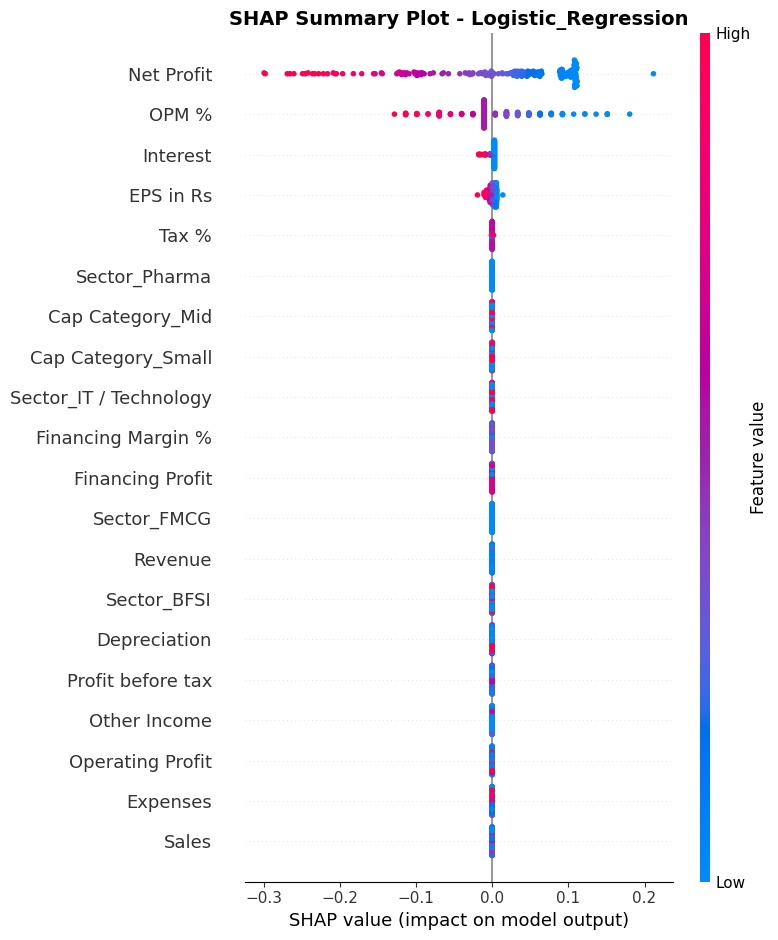

   Creating Feature Importance Bar Plot...


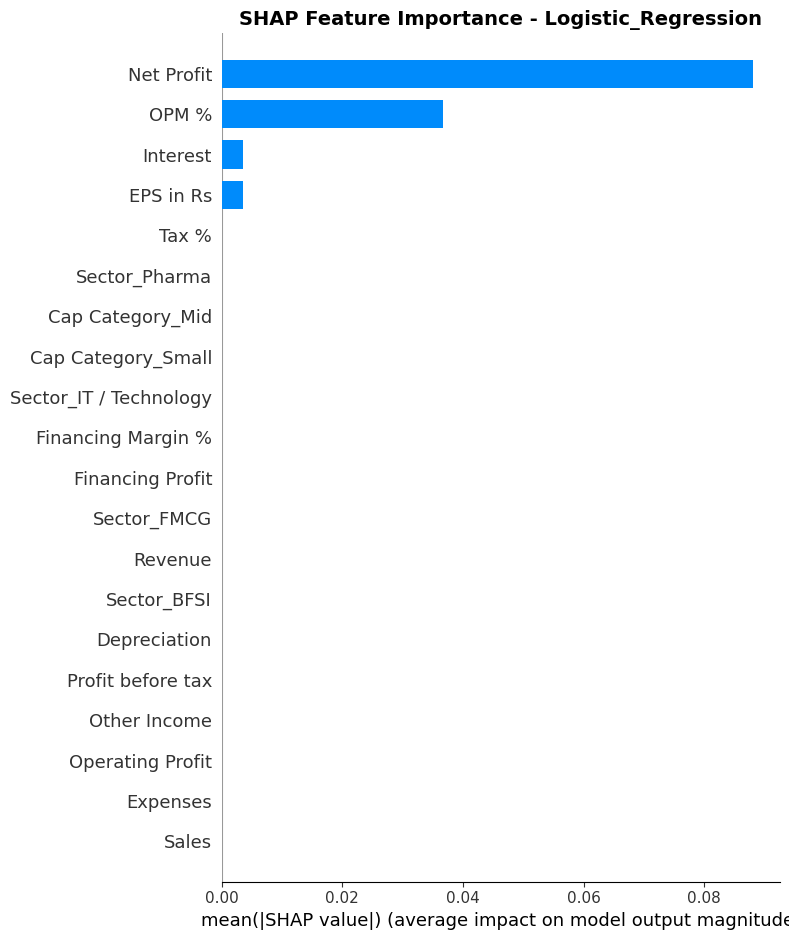

   Creating Waterfall Plot for first prediction...


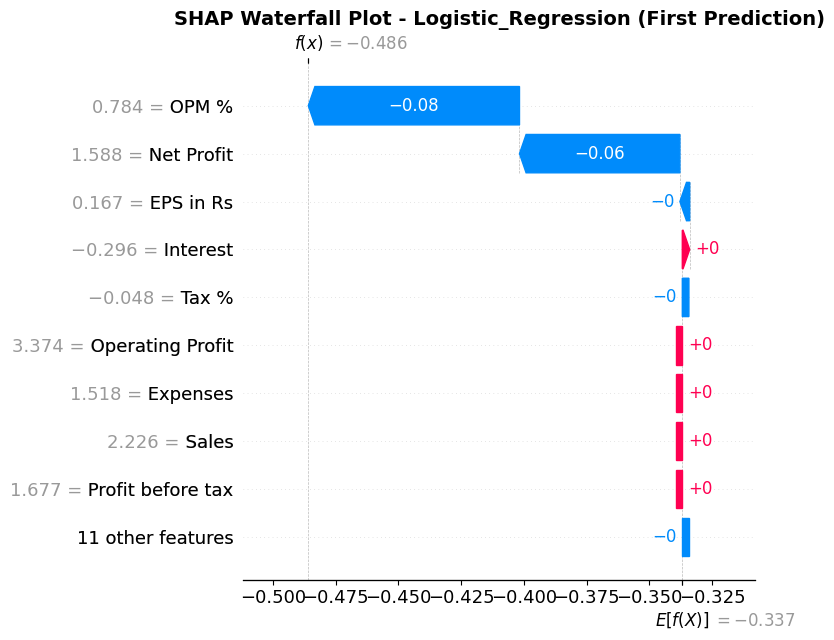

   Visualizations completed for Logistic_Regression

Creating visualizations for Random_Forest...
   Creating Summary Plot...


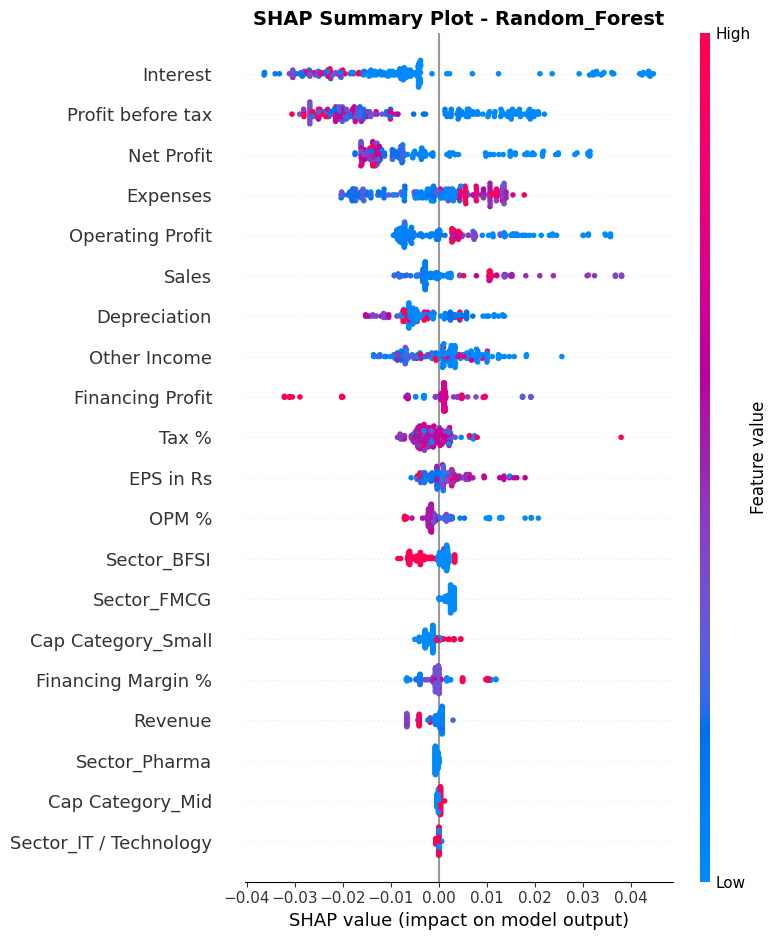

   Creating Feature Importance Bar Plot...


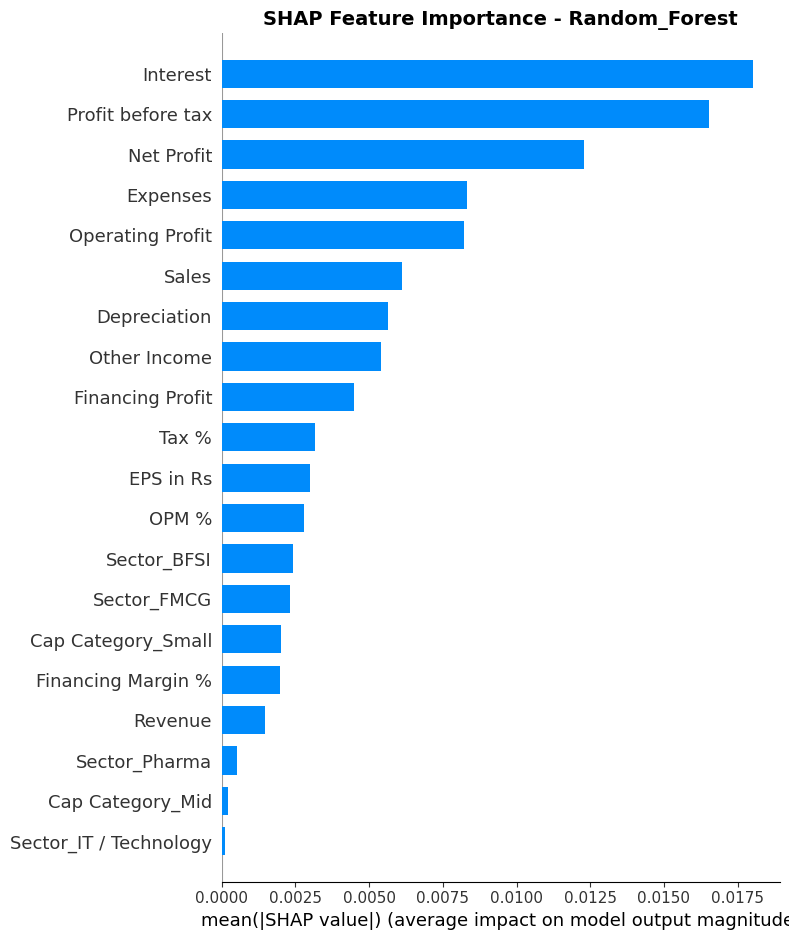

   Creating Waterfall Plot for first prediction...


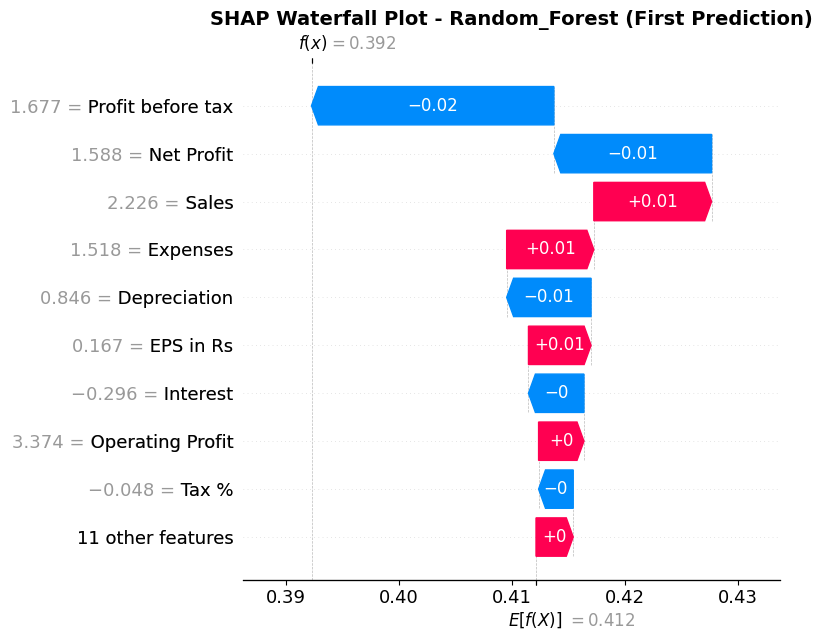

   Visualizations completed for Random_Forest

Creating visualizations for XGBoost...
   Creating Summary Plot...


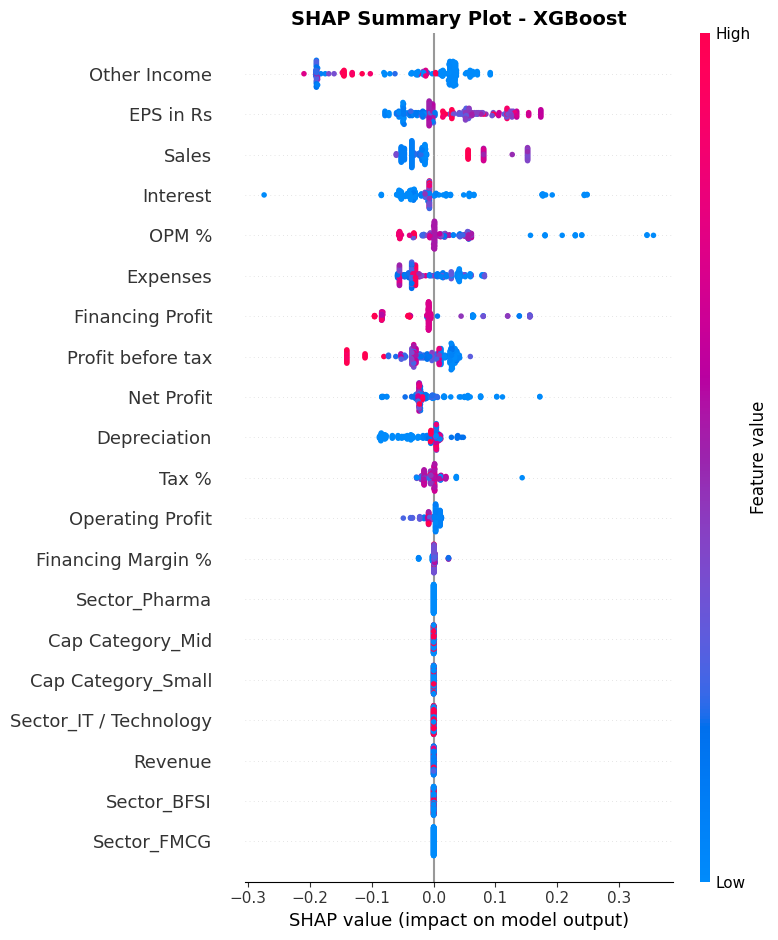

   Creating Feature Importance Bar Plot...


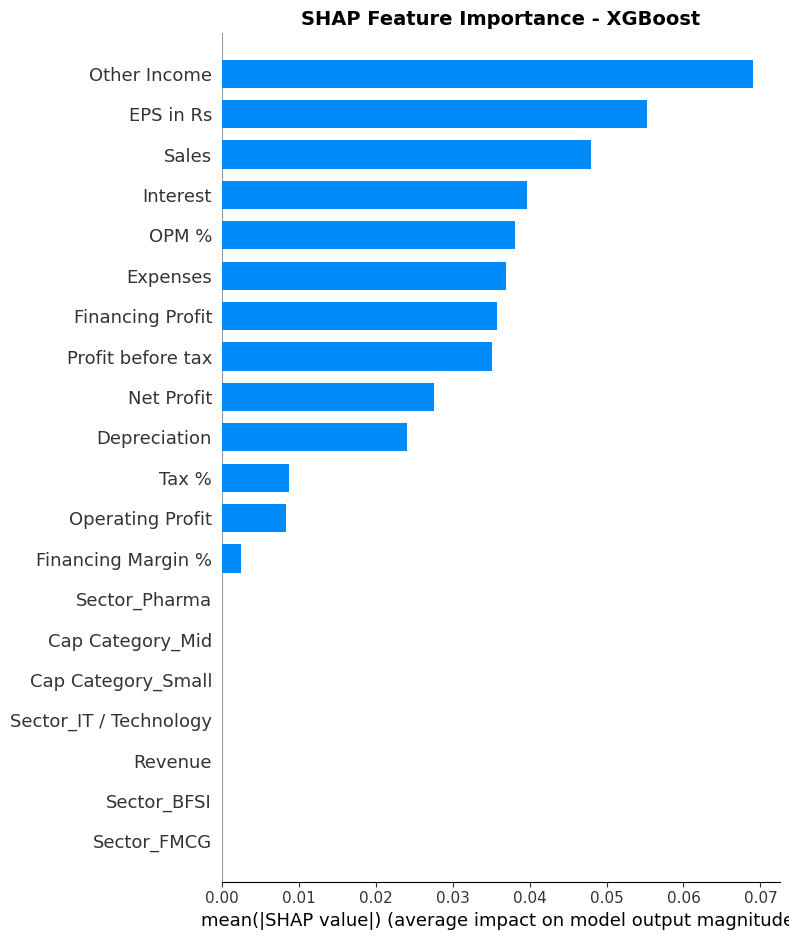

   Creating Waterfall Plot for first prediction...


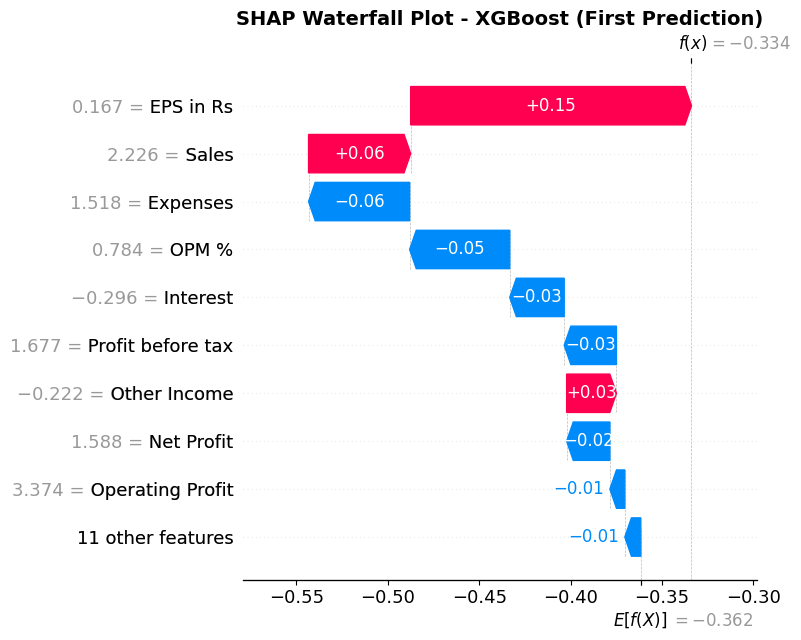

   Visualizations completed for XGBoost




In [22]:
print("=" * 40)

# Create visualizations for each model
for model_name in complete_shap_results.keys():
    print(f"Creating visualizations for {model_name}...")

    # Get SHAP data
    shap_data = complete_shap_results[model_name]
    shap_values = shap_data['shap_values']
    feature_names = shap_data['feature_names']
    X_transformed = shap_data['X_transformed']
    expected_value = shap_data['expected_value']

    # Clean feature names for better display
    clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

    print("   Creating Summary Plot...")
    # 1. SHAP Summary Plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_transformed, feature_names=clean_feature_names, show=False)
    plt.title(f'SHAP Summary Plot - {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_summary_{model_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("   Creating Feature Importance Bar Plot...")
    # 2. SHAP Feature Importance Bar Plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_transformed, feature_names=clean_feature_names,
                     plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_importance_{model_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("   Creating Waterfall Plot for first prediction...")
    # 3. SHAP Waterfall Plot (for first prediction)
    plt.figure(figsize=(10, 8))
    try:
        shap.waterfall_plot(
            shap.Explanation(values=shap_values[0],
                           base_values=expected_value,
                           data=X_transformed[0],
                           feature_names=clean_feature_names),
            show=False
        )
        plt.title(f'SHAP Waterfall Plot - {model_name} (First Prediction)',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_{model_name.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"   Waterfall plot failed: {str(e)}")

    print(f"   Visualizations completed for {model_name}")
    print()

print()

# SHAP ANALYSIS - Consolidate and Final

Loading and preparing data...
Data prepared: 584 samples, 22 features
Final dataset: 584 samples, 16 features
Train-test split: Train (467, 16), Test (117, 16)

 Performing SHAP Analysis...
Sample size: 25, Background size: 40

🔍 Processing Logistic_Regression...


100%|██████████| 25/25 [00:09<00:00,  2.72it/s]


   Success! Expected value: 0.4203
   Top 5 features:
      1. Net Profit: 0.0202
      2. OPM %: 0.0156
      3. EPS in Rs: 0.0012
      4. Interest: 0.0006
      5. Tax %: 0.0000

🔍 Processing Random_Forest...


100%|██████████| 25/25 [00:12<00:00,  2.06it/s]


   Success! Expected value: 0.3993
   Top 5 features:
      1. Profit before tax: 0.0199
      2. Interest: 0.0145
      3. Net Profit: 0.0104
      4. Depreciation: 0.0075
      5. Operating Profit: 0.0068

🔍 Processing XGBoost...


100%|██████████| 25/25 [00:09<00:00,  2.76it/s]


   Success! Expected value: 0.3986
   Top 5 features:
      1. EPS in Rs: 0.0175
      2. OPM %: 0.0164
      3. Other Income: 0.0140
      4. Interest: 0.0119
      5. Profit before tax: 0.0119

 SHAP Analysis Complete! 3 models analyzed.

 Creating SHAP visualizations...


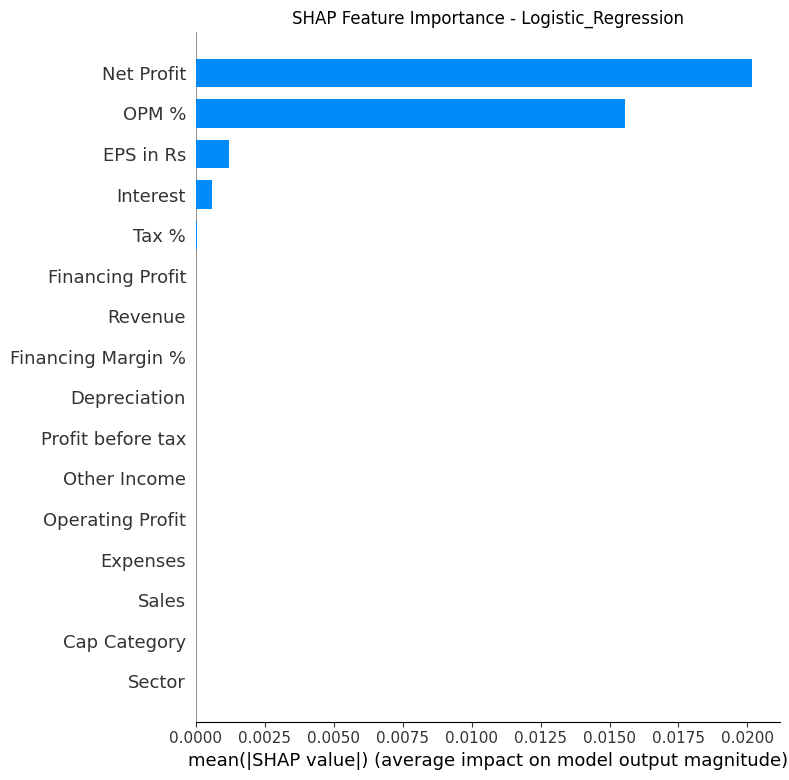

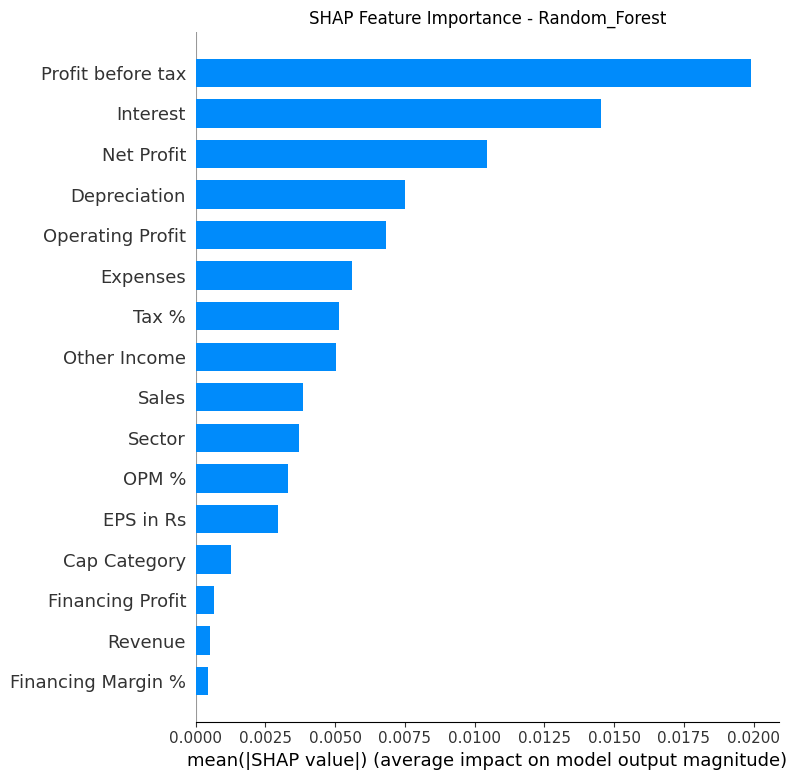

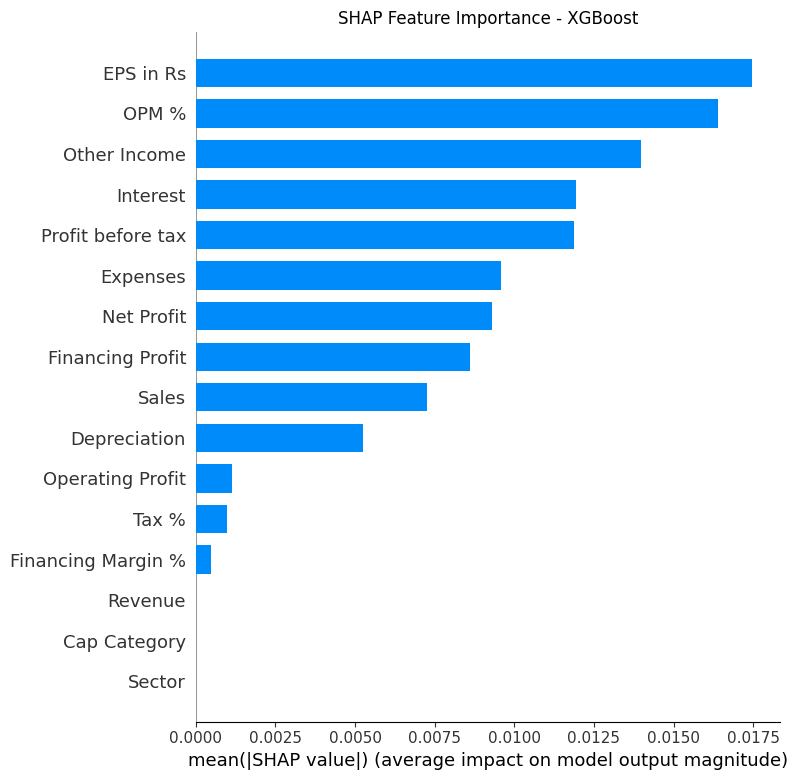


 Feature Importance Comparison:

Top 10 Most Important Features (Average across models):
                   Logistic_Regression  Random_Forest  XGBoost  Average
Net Profit                      0.0202         0.0104   0.0093   0.0133
OPM %                           0.0156         0.0033   0.0164   0.0118
Profit before tax               0.0000         0.0199   0.0119   0.0106
Interest                        0.0006         0.0145   0.0119   0.0090
EPS in Rs                       0.0012         0.0030   0.0175   0.0072
Other Income                    0.0000         0.0050   0.0140   0.0063
Expenses                        0.0000         0.0056   0.0096   0.0051
Depreciation                    0.0000         0.0075   0.0053   0.0043
Sales                           0.0000         0.0038   0.0073   0.0037
Financing Profit                0.0000         0.0007   0.0086   0.0031


<Figure size 1200x800 with 0 Axes>

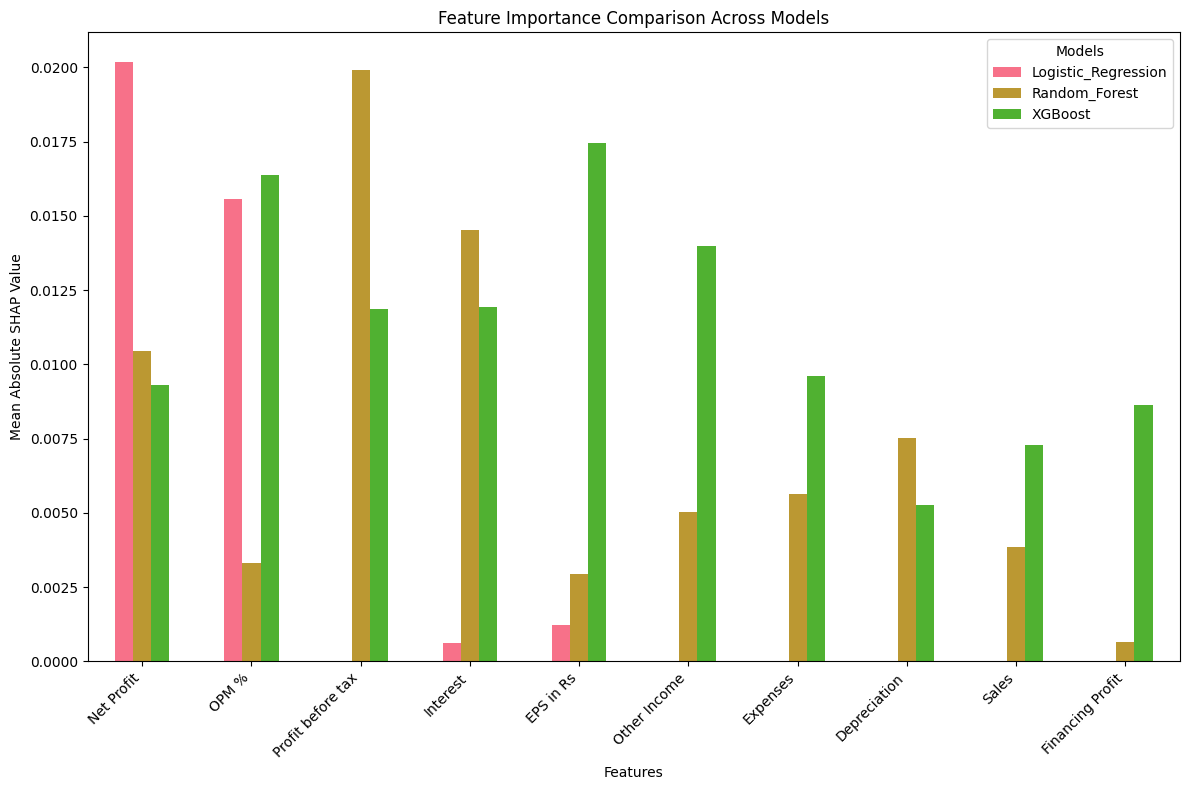

In [28]:

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Step 1: Load and prepare the data
print("Loading and preparing data...")

# Load the clean dataset
df = pd.read_excel('MS_Capstone_Final_Quality_Check_Summary.xlsx', sheet_name='clean_data')

# Define features and target
feature_columns = [
    'Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income', 'Interest', 
    'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs', 
    'Revenue', 'Financing Profit', 'Financing Margin %', 'Closing Price (T)', 
    'Closing Price (T+1)', 'Closing Price (T+2)', 'Closing Price (T+3)', 
    '3-Day Avg Price Post Result', '3-Day Return (%)', 'Sector', 'Cap Category'
]

target_column = 'Movement Label (1,0)'

# Create feature matrix and target vector
X_complete = df[feature_columns].copy()
y_complete = df[target_column].copy()

# Handle missing values
valid_indices = y_complete.notna()
X_clean = X_complete[valid_indices].copy()
y_clean = y_complete[valid_indices].copy()

# Fill any remaining missing values in features
for col in X_clean.columns:
    if X_clean[col].isnull().sum() > 0:
        if X_clean[col].dtype in ['object', 'category']:
            mode_val = X_clean[col].mode()
            if len(mode_val) > 0:
                X_clean[col] = X_clean[col].fillna(mode_val[0])
            else:
                X_clean[col] = X_clean[col].fillna('Unknown')
        else:
            X_clean[col] = X_clean[col].fillna(X_clean[col].median())

print(f"Data prepared: {X_clean.shape[0]} samples, {X_clean.shape[1]} features")

# Step 2: Use the exact features your pipelines expect
expected_features = [
    'Sector', 'Cap Category', 'Sales', 'Expenses', 'Operating Profit', 'OPM %',
    'Other Income', 'Interest', 'Depreciation', 'Profit before tax', 'Tax %',
    'Net Profit', 'EPS in Rs', 'Revenue', 'Financing Profit', 'Financing Margin %'
]

X_final = X_clean[expected_features].copy()
y_final = y_clean.copy()

print(f"Final dataset: {X_final.shape[0]} samples, {X_final.shape[1]} features")

# Step 3: Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"Train-test split: Train {X_train.shape}, Test {X_test.shape}")

# Step 4: SHAP Analysis
print("\n Performing SHAP Analysis...")

# Use manageable sample sizes
sample_size = min(25, X_test.shape[0])
background_size = min(40, X_train.shape[0])

# Convert to numpy arrays
X_sample_np = X_test.iloc[:sample_size].values
X_background_np = X_train.iloc[:background_size].values
feature_names = list(X_test.columns)

print(f"Sample size: {sample_size}, Background size: {background_size}")

# Store SHAP results
shap_results = {}

# Analyze each model
for model_name, pipeline in tuned_models.items():
    print(f"\n🔍 Processing {model_name}...")
    
    try:
        # Create prediction function
        def model_predict_proba_np(X_np):
            X_df = pd.DataFrame(X_np, columns=feature_names)
            return pipeline.predict_proba(X_df)[:, 1]
        
        # Create SHAP explainer
        explainer = shap.KernelExplainer(model_predict_proba_np, X_background_np)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(X_sample_np)
        
        # Store results
        shap_results[model_name] = {
            'explainer': explainer,
            'shap_values': shap_values,
            'expected_value': explainer.expected_value,
            'feature_names': feature_names,
            'X_sample': X_sample_np
        }
        
        print(f"   Success! Expected value: {explainer.expected_value:.4f}")
        
        # Show top features
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        top_indices = np.argsort(mean_abs_shap)[-5:][::-1]
        
        print(f"   Top 5 features:")
        for i, idx in enumerate(top_indices):
            print(f"      {i+1}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")
        
    except Exception as e:
        print(f"   Error: {str(e)}")

print(f"\n SHAP Analysis Complete! {len(shap_results)} models analyzed.")

# Step 5: Create visualizations
if len(shap_results) > 0:
    print("\n Creating SHAP visualizations...")
    
    # Summary plot for each model
    for model_name, results in shap_results.items():
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            results['shap_values'], 
            pd.DataFrame(results['X_sample'], columns=results['feature_names']),
            plot_type="bar",
            show=False
        )
        plt.title(f'SHAP Feature Importance - {model_name}')
        plt.tight_layout()
        plt.show()
    
    # Feature importance comparison
    print("\n Feature Importance Comparison:")
    all_features = feature_names
    importance_comparison = {}
    
    for feature in all_features:
        importance_comparison[feature] = {}
        for model_name, results in shap_results.items():
            shap_vals = results['shap_values']
            feature_idx = results['feature_names'].index(feature)
            mean_abs_importance = np.mean(np.abs(shap_vals[:, feature_idx]))
            importance_comparison[feature][model_name] = mean_abs_importance
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(importance_comparison).T
    comparison_df['Average'] = comparison_df.mean(axis=1)
    comparison_df = comparison_df.sort_values('Average', ascending=False)
    
    print("\nTop 10 Most Important Features (Average across models):")
    print(comparison_df.head(10).round(4))
    
    # Plot comparison
    plt.figure(figsize=(12, 8))
    comparison_df.head(10)[['Logistic_Regression', 'Random_Forest', 'XGBoost']].plot(kind='bar')
    plt.title('Feature Importance Comparison Across Models')
    plt.xlabel('Features')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Models')
    plt.tight_layout()
    plt.show()


# WIP - PERMUTATION IMPORTANCE ANALYSIS  - (Not added in the report yet will be a part of final report.)


 Parameters: 5 repeats, scoring=accuracy

 Processing Logistic_Regression...
   Baseline accuracy: 0.5983
   Calculating permutation importance...
   Success! Calculated importance for 16 features
   Top 5 most important features:
      1. OPM %: 0.0103 (±0.0034)
      2. Net Profit: 0.0034 (±0.0042)
      3. Sector: 0.0000 (±0.0000)
      4. Cap Category: 0.0000 (±0.0000)
      5. Sales: 0.0000 (±0.0000)

 Processing Random_Forest...
   Baseline accuracy: 0.6239
   Calculating permutation importance...
   Success! Calculated importance for 16 features
   Top 5 most important features:
      1. Other Income: 0.0103 (±0.0147)
      2. Net Profit: 0.0051 (±0.0087)
      3. Revenue: 0.0017 (±0.0034)
      4. Expenses: -0.0017 (±0.0064)
      5. Financing Margin %: -0.0017 (±0.0034)

 Processing XGBoost...
   Baseline accuracy: 0.6239
   Calculating permutation importance...
   Success! Calculated importance for 16 features
   Top 5 most important features:
      1. OPM %: 0.0342 (±0.0216)

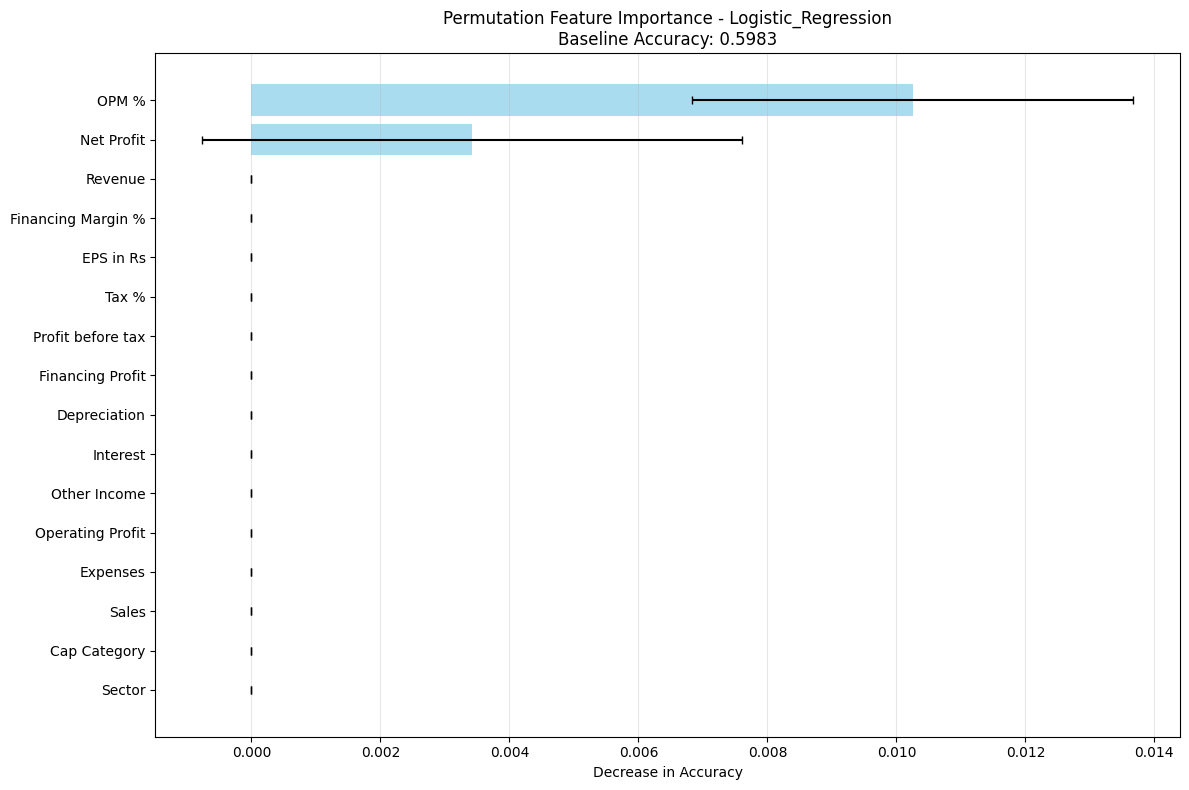

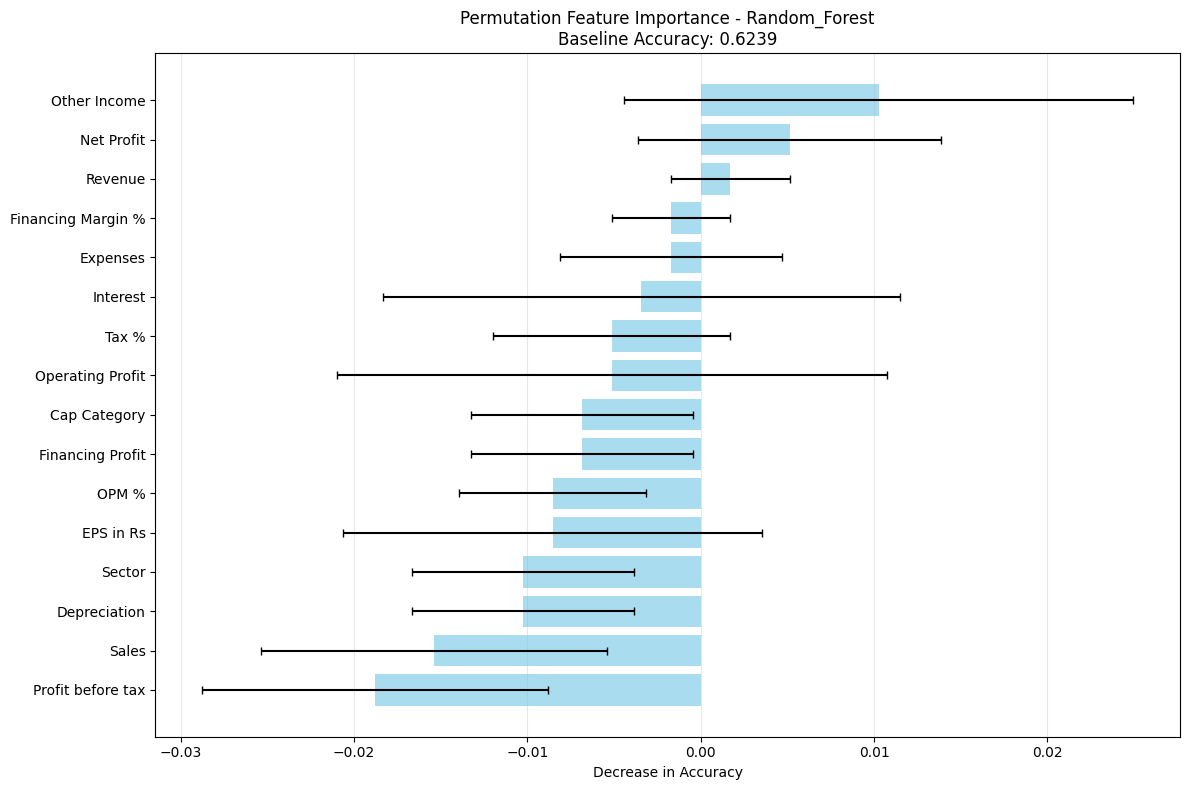

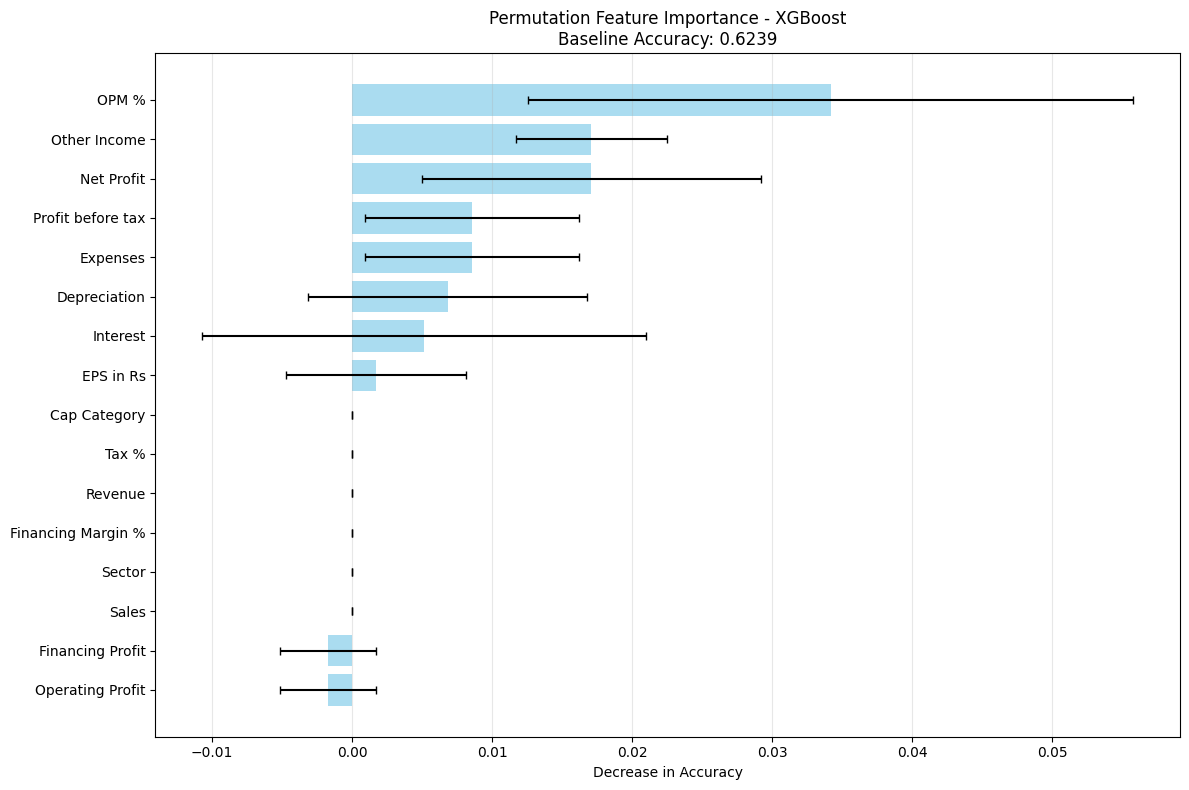


 Creating model comparison...


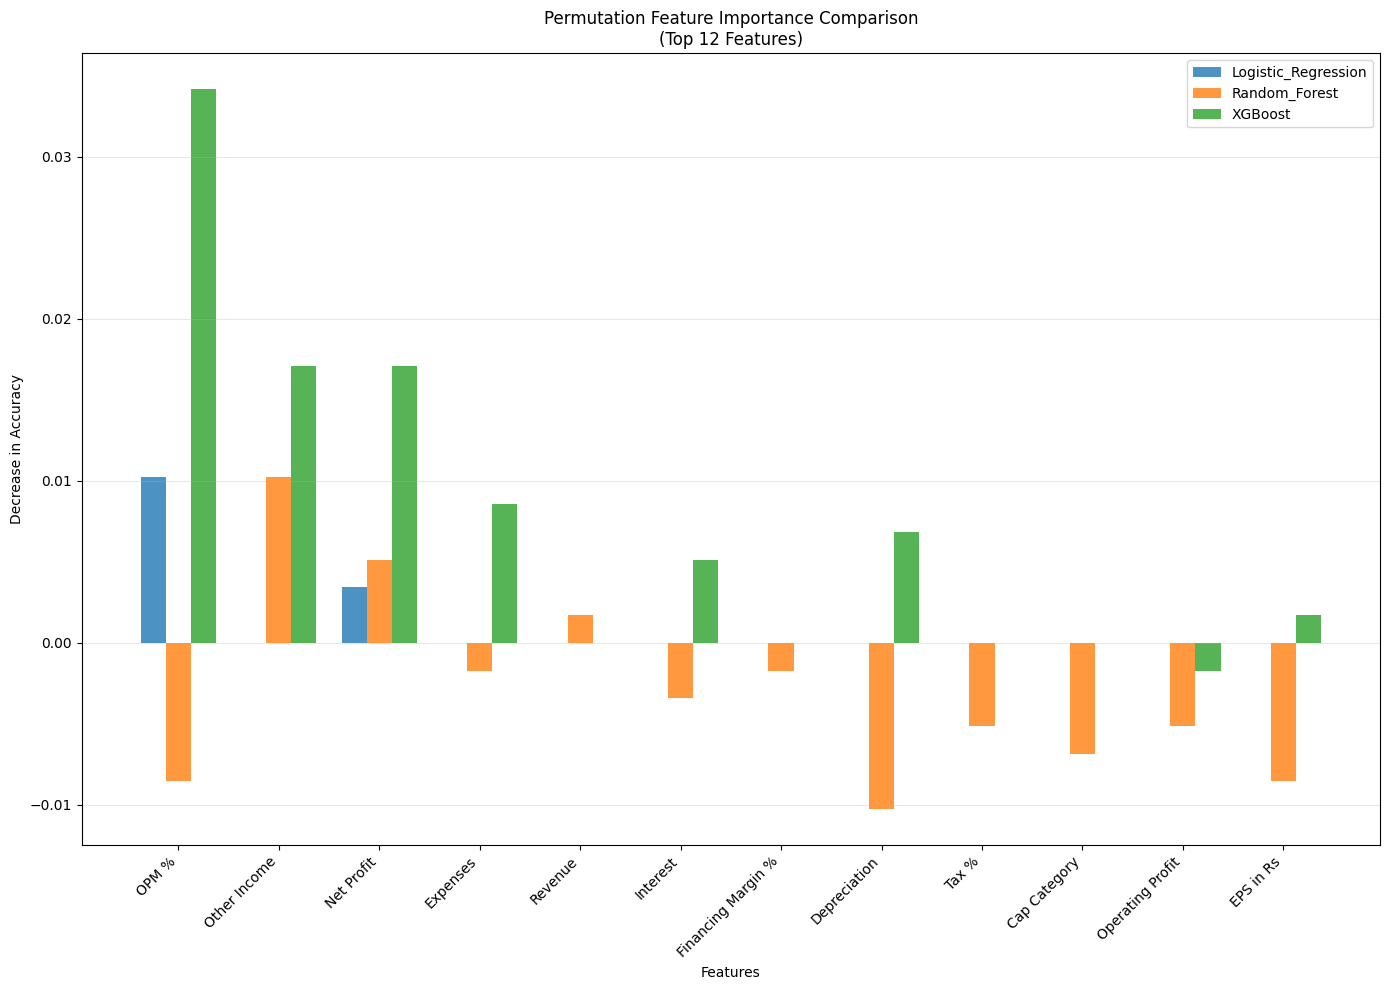


 PERMUTATION IMPORTANCE SUMMARY:

Top 10 Most Important Features (Average across models):
                    Logistic_Regression  Random_Forest  XGBoost  Average
OPM %                            0.0103        -0.0085   0.0342   0.0120
Other Income                     0.0000         0.0103   0.0171   0.0091
Net Profit                       0.0034         0.0051   0.0171   0.0085
Expenses                         0.0000        -0.0017   0.0085   0.0023
Revenue                          0.0000         0.0017   0.0000   0.0006
Interest                         0.0000        -0.0034   0.0051   0.0006
Financing Margin %               0.0000        -0.0017   0.0000  -0.0006
Depreciation                     0.0000        -0.0103   0.0068  -0.0011
Tax %                            0.0000        -0.0051   0.0000  -0.0017
Cap Category                     0.0000        -0.0068   0.0000  -0.0023

 MODEL PERFORMANCE SUMMARY:
-----------------------------------

Model Performance Statistics:
          

In [32]:
# PERMUTATION IMPORTANCE ANALYSIS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import pandas as pd


# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Store permutation importance results
perm_importance_results = {}

# Parameters for permutation importance
n_repeats = 5
random_state = 42
scoring = 'accuracy'

print(f" Parameters: {n_repeats} repeats, scoring={scoring}")

# Analyze each model in tuned_models
for model_name, pipeline in tuned_models.items():
    print(f"\n Processing {model_name}...")
    
    try:
        # Calculate baseline performance
        y_pred = pipeline.predict(X_test)
        baseline_score = accuracy_score(y_test, y_pred)
        
        print(f"   Baseline accuracy: {baseline_score:.4f}")
        
        # Calculate permutation importance
        print(f"   Calculating permutation importance...")
        perm_imp = permutation_importance(
            pipeline, X_test, y_test,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring=scoring,
            n_jobs=-1
        )
        
        # Store results
        perm_importance_results[model_name] = {
            'importances_mean': perm_imp.importances_mean,
            'importances_std': perm_imp.importances_std,
            'importances': perm_imp.importances,
            'feature_names': X_test.columns.tolist(),
            'baseline_score': baseline_score
        }
        
        print(f"   Success! Calculated importance for {len(X_test.columns)} features")
        
        # Show top features
        feature_importance = list(zip(X_test.columns, perm_imp.importances_mean))
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        
        print(f"   Top 5 most important features:")
        for i, (feature, importance) in enumerate(feature_importance[:5]):
            feature_idx = list(X_test.columns).index(feature)
            std_dev = perm_imp.importances_std[feature_idx]
            print(f"      {i+1}. {feature}: {importance:.4f} (±{std_dev:.4f})")
        
    except Exception as e:
        print(f"   Error: {str(e)}")

print(f"\n🎉 Permutation Importance Analysis Complete! {len(perm_importance_results)} models analyzed.")

# Create visualizations
if len(perm_importance_results) > 0:
    print("\n Creating visualizations...")
    
    # 1. Individual model plots
    for model_name, results in perm_importance_results.items():
        plt.figure(figsize=(12, 8))
        
        # Create DataFrame for plotting
        importance_df = pd.DataFrame({
            'Feature': results['feature_names'],
            'Importance': results['importances_mean'],
            'Std': results['importances_std']
        }).sort_values('Importance', ascending=True)
        
        # Horizontal bar plot with error bars
        plt.barh(range(len(importance_df)), importance_df['Importance'], 
                xerr=importance_df['Std'], capsize=3, alpha=0.7, color='skyblue')
        plt.yticks(range(len(importance_df)), importance_df['Feature'])
        plt.xlabel('Decrease in Accuracy')
        plt.title(f'Permutation Feature Importance - {model_name}\nBaseline Accuracy: {results["baseline_score"]:.4f}')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # 2. Comparison across models
    print("\n Creating model comparison...")
    
    # Create comparison DataFrame
    comparison_data = {}
    for model_name, results in perm_importance_results.items():
        comparison_data[model_name] = results['importances_mean']
    
    feature_names = perm_importance_results[list(perm_importance_results.keys())[0]]['feature_names']
    comparison_df = pd.DataFrame(comparison_data, index=feature_names)
    comparison_df['Average'] = comparison_df.mean(axis=1)
    comparison_df = comparison_df.sort_values('Average', ascending=False)
    
    # Plot comparison (top 12 features)
    plt.figure(figsize=(14, 10))
    top_features = comparison_df.head(12)
    
    x = np.arange(len(top_features))
    width = 0.25
    models = list(perm_importance_results.keys())
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, model in enumerate(models):
        plt.bar(x + i*width, top_features[model], width, 
               label=model, alpha=0.8, color=colors[i % len(colors)])
    
    plt.xlabel('Features')
    plt.ylabel('Decrease in Accuracy')
    plt.title('Permutation Feature Importance Comparison\n(Top 12 Features)')
    plt.xticks(x + width, top_features.index, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Summary table
    print("\n PERMUTATION IMPORTANCE SUMMARY:")
    print("=" * 50)
    print("\nTop 10 Most Important Features (Average across models):")
    summary_df = comparison_df.head(10).round(4)
    print(summary_df)
    
    # 4. Model performance summary
    print("\n MODEL PERFORMANCE SUMMARY:")
    print("-" * 35)
    
    performance_summary = {}
    for model_name, results in perm_importance_results.items():
        performance_summary[model_name] = {
            'Baseline_Accuracy': results['baseline_score'],
            'Top_Feature_Importance': max(results['importances_mean']),
            'Avg_Feature_Importance': np.mean(results['importances_mean']),
            'Num_Important_Features': sum(1 for x in results['importances_mean'] if x > 0.001)
        }
    
    performance_df = pd.DataFrame(performance_summary).T
    print("\nModel Performance Statistics:")
    print(performance_df.round(4))

